# EDA — raw movie features

**Goal.** Understand the movie features in their raw, not-yet-encoded form (`movies_features-raw.csv`, output of `03_cleaning_moviesData.ipynb`) before choosing encodings and transformations. The questions:

| Question | Section |
|---|---|
| Are there missing, empty or impossible values? | 2 |
| What does the target (per-movie mean rating and its spread) look like? | 3 |
| Are the numeric features skewed, does a log scale fix them, and which are related to the rating? | 4 |
| How are genres distributed, which appear together, which go with higher ratings? | 5 |
| How many production companies / countries should be kept as top-X one-hot + `other`? | 6, 7 |
| How should language be encoded? | 8 |
| How are directors distributed, and does the director matter for the rating? | 9 |
| Should actors be used, and how (which score, how many billed actors)? | 10 |
| Which non-numeric features are related to the rating, and how much does each feature group explain? | 11 |

Section 12 collects the resulting encoding and transformation decisions. These feed the research questions in `docs/01_proposal.md`: persona clustering (RQ1), polarization (RQ2), feature importance (RQ3) and the prediction model (RQ4).

## 1. Load and parse

The list columns (genres, companies, countries, spoken languages, cast) are stored as text such as `"['Drama', 'Comedy']"`, so they are parsed back into Python lists while reading. Ratings are loaded with only the needed columns and compact types (~57M rows) and aggregated per movie into `avg_rating` (mean stars), `rating_std` (spread, the polarization measure) and `n_ratings`.

In [1]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROCESSED = Path("../data/processed")
LIST_COLS = ["genre_names", "company_names", "country_names", "language_names", "cast_names"]

movies = pd.read_csv(
    PROCESSED / "movies_features-raw.csv",
    converters={c: ast.literal_eval for c in LIST_COLS},
)
ratings = pd.read_csv(
    PROCESSED / "ratings.csv",
    usecols=["netflix_movie_id", "rating"],
    dtype={"netflix_movie_id": "int32", "rating": "int8"},
)
print(f"movies: {movies.shape} | ratings: {ratings.shape}")
movies.head(3)

movies: (1322, 16) | ratings: (57186566, 2)


,netflix_movie_id,title,year,budget,original_language,revenue,runtime,genre_names,company_names,country_names,language_names,cast_names,director,actor_1,actor_2,actor_3
0,30,Something's Gotta Give,2003.0,80000000,en,266728738,128.0,"[Drama, Comedy, Romance]","[Columbia Pictures Corporation, Waverly Films,...",[United States of America],"[Français, English]","[Jack Nicholson, Diane Keaton, Keanu Reeves, F...",Nancy Meyers,Jack Nicholson,Diane Keaton,Keanu Reeves
1,55,Jade,1995.0,50000000,en,9851610,95.0,"[Action, Thriller, Mystery, Romance]",[Paramount Pictures],[United States of America],[English],"[David Caruso, Linda Fiorentino, Chazz Palmint...",William Friedkin,David Caruso,Linda Fiorentino,Chazz Palminteri
2,58,Dragonheart,1996.0,57000000,en,115267375,103.0,[Fantasy],[Universal Pictures],[United States of America],[English],"[Dennis Quaid, David Thewlis, Pete Postlethwai...",Rob Cohen,Dennis Quaid,David Thewlis,Pete Postlethwaite


In [ ]:
### aggregation
movie_rating_stats = (
    ratings.groupby("netflix_movie_id")["rating"]
    .agg(avg_rating="mean", rating_std="std", n_ratings="count")
    .reset_index()
)
movies = movies.merge(movie_rating_stats, on="netflix_movie_id", how="left")
print("movies without ratings:", int(movies["avg_rating"].isna().sum()))

movies without ratings: 0


Helper functions reused in several sections:
- `explode_counts`: how many movies each name (genre, company, …) appears in.
- `plot_top_bar`: horizontal bar chart of the most frequent names.
- `per_movie_count_bar`: how many names each movie has (e.g. companies per movie).
- `coverage_table` / `plot_coverage`: for a top-X one-hot encoding, how much of the data the top-X names cover (sections 6, 7, 9).
- `plot_vs_rating`: scatter of a feature against a rating statistic, with a trend line.

In [ ]:
def explode_counts(lists):
    return lists.explode().dropna().value_counts()


def plot_top_bar(counts, n, title, xlabel="movies"):
    top = counts.head(n)[::-1]
    fig, ax = plt.subplots(figsize=(8, max(3, 0.26 * len(top))))
    ax.barh(top.index, top.values, color="steelblue")
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


def per_movie_count_bar(lists, title, cap=10):
    n = lists.map(len).clip(upper=cap)
    counts = n.value_counts().sort_index()
    labels = [f"{k}+" if k == cap else str(k) for k in counts.index]
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(labels, counts.values, color="steelblue")
    ax.set_xlabel("items per movie")
    ax.set_ylabel("movies")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


def coverage_table(lists, counts, xs):
    """For each X: share of movies with >=1 top-X item, and share of all item mentions that are top-X."""
    total_mentions = counts.sum()
    rows = []
    for x in xs:
        top = set(counts.index[:x])
        rows.append({
            "X": x,
            "min_movies_per_kept_item": int(counts.iloc[x - 1]),
            "pct_movies_with_top_item": 100 * lists.map(lambda items: any(i in top for i in items)).mean(),
            "pct_mentions_covered": 100 * counts.iloc[:x].sum() / total_mentions,
        })
    return pd.DataFrame(rows).set_index("X").round(1)


def plot_coverage(lists, counts, max_x, marks, title):
    xs = list(range(1, min(max_x, len(counts)) + 1))
    cov = coverage_table(lists, counts, xs)
    fig, ax = plt.subplots(figsize=(8, 3.8))
    ax.plot(cov.index, cov["pct_movies_with_top_item"], color="steelblue", label="% movies with ≥1 top-X item")
    ax.plot(cov.index, cov["pct_mentions_covered"], color="#dd8452", label="% of all mentions covered")
    for m in marks:
        if m in cov.index:
            ax.axvline(m, color="gray", ls=":", lw=0.8)
            ax.annotate(f"X={m}", (m, 3), fontsize=8, color="gray")
    ax.set_xlabel("X = number of most frequent items kept as one-hot columns")
    ax.set_ylabel("%")
    ax.set_ylim(0, 100)
    ax.legend(loc="lower right", fontsize=8)
    ax.set_title(title)
    fig.tight_layout()
    plt.show()
    #return cov.loc[[m for m in marks if m in cov.index]]


def binned_mean(x, y, q=15):
    bins = pd.qcut(x, q=q, duplicates="drop")
    g = pd.DataFrame({"x": x, "y": y}).groupby(bins, observed=True).mean()
    return g["x"], g["y"]


def plot_vs_rating(df, col, target, ax, logx=False):
    d = df[[col, target]].dropna()
    x = np.log10(d[col]) if logx else d[col]
    ax.scatter(d[col], d[target], s=5, alpha=0.3, color="steelblue")
    bx, by = binned_mean(x, d[target])
    ax.plot(10 ** bx if logx else bx, by, color="#c44e52", marker="o", ms=3)
    if logx:
        ax.set_xscale("log")
    pear = x.corr(d[target])
    spear = d[col].corr(d[target], method="spearman")
    ax.set_title(f"{col}: Pearson{'(log)' if logx else ''}={pear:.2f}  Spearman={spear:.2f}", fontsize=9)
    ax.set_xlabel(col + (" (log scale)" if logx else ""))
    ax.set_ylabel(target)


def rating_boxplot(groups, title, ref=None):
    """groups: dict label -> Series of avg_rating. Box plot with n in labels."""
    fig, ax = plt.subplots(figsize=(8, max(3, 0.32 * len(groups))))
    ax.boxplot(list(groups.values()), vert=False, patch_artist=True,
               boxprops={"facecolor": "lightsteelblue"}, flierprops={"markersize": 2})
    ax.set_yticks(range(1, len(groups) + 1))
    ax.set_yticklabels([f"{k} (n={len(v)})" for k, v in groups.items()])
    if ref is not None:
        ax.axvline(ref, color="#c44e52", ls="--", lw=1, label=f"all movies median = {ref:.2f}")
        ax.legend(fontsize=8, loc="lower right")
    ax.set_xlabel("avg_rating")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()

## 2. Data quality

Before plotting distributions, check for missing values, duplicates, empty lists and impossible values. A handful of errors can dominate a histogram or a correlation (a budget of \$1 makes the revenue/budget ratio millions of times larger than normal).

In [4]:
print("missing values per column:")
print(movies.isna().sum()[lambda s: s > 0].to_string())
print("\nduplicate netflix_movie_id:", int(movies["netflix_movie_id"].duplicated().sum()))
print("duplicate title:", int(movies["title"].duplicated().sum()))

pd.DataFrame({
    "empty_lists": [int((movies[c].map(len) == 0).sum()) for c in LIST_COLS],
    "unique_values": [movies[c].explode().nunique() for c in LIST_COLS],
}, index=LIST_COLS)

missing values per column:
actor_2    2
actor_3    3

duplicate netflix_movie_id: 0
duplicate title: 0


,empty_lists,unique_values
genre_names,0,19
company_names,14,1414
country_names,5,42
language_names,1,45
cast_names,0,19563


In [5]:
# TMDB sometimes stores money in millions or as placeholders (e.g. budget = 1)
SUSPECT_MONEY = 1_000
suspect = (movies["budget"] < SUSPECT_MONEY) | (movies["revenue"] < SUSPECT_MONEY)
print(f"movies with budget or revenue < ${SUSPECT_MONEY:,}: {int(suspect.sum())}")
display(movies.loc[suspect, ["title", "year", "budget", "revenue"]].sort_values("budget"))

movies["roi"] = movies["revenue"] / movies["budget"]
movies_ok = movies[~suspect].copy()
print(f"movies used for numeric analysis: {len(movies_ok)}")
movies_ok[["year", "runtime", "budget", "revenue", "roi"]].describe().round(1)

movies with budget or revenue < $1,000: 8


,title,year,budget,revenue
124,Modern Times,1936.0,1,8500000
111,A Farewell to Arms,1932.0,4,25
963,The Prophecy,1995.0,8,16
741,Angela's Ashes,1999.0,25,13
904,Rugrats in Paris: The Movie,2000.0,30,103
1071,In the Cut,2003.0,12000000,23
12,The Cookout,2004.0,16000000,12
325,Chasing Liberty,2004.0,23000000,12


movies used for numeric analysis: 1314


,year,runtime,budget,revenue,roi
count,1314.0,1314.0,1314.0,1.314000e+03,1314.0
mean,1993.9,112.8,34994670.3,9.984537e+07,10.2
std,12.7,21.8,32886898.2,1.334439e+08,118.4
min,1916.0,69.0,7000.0,1.487300e+04,0.0
25%,1991.0,97.0,10000000.0,1.827624e+07,1.1
50%,1998.0,108.0,25000000.0,5.229070e+07,2.3
75%,2002.0,124.0,50000000.0,1.287018e+08,4.8
max,2005.0,219.0,200000000.0,1.845034e+09,4133.3


**Observations**

- 1,322 movies, no duplicates; every movie has ratings. The only missing values are `actor_2` / `actor_3` in 2–3 films with a very small cast.
- Empty lists: 14 movies without any production company, 5 without a country, 1 without a spoken language. Encoders must handle an empty list (all zeros, or an explicit `unknown`).
- **8 movies have impossible budget or revenue values** (e.g. *Modern Times* budget = \$1, *The Cookout* revenue = \$12): TMDB entry errors. They would create revenue/budget ratios in the millions. They are excluded from the numeric sections; **recommendation: drop or fix them in `03_cleaning_moviesData.ipynb`**. (*Primer*, budget \$7,000, is real and stays.)

## 3. Target — per-movie rating statistics

Every later "feature vs. rating" plot is read against these distributions. `avg_rating` is the main prediction target; `rating_std` measures how much raters disagree (RQ2, polarization); `n_ratings` measures popularity and how reliable the mean is.

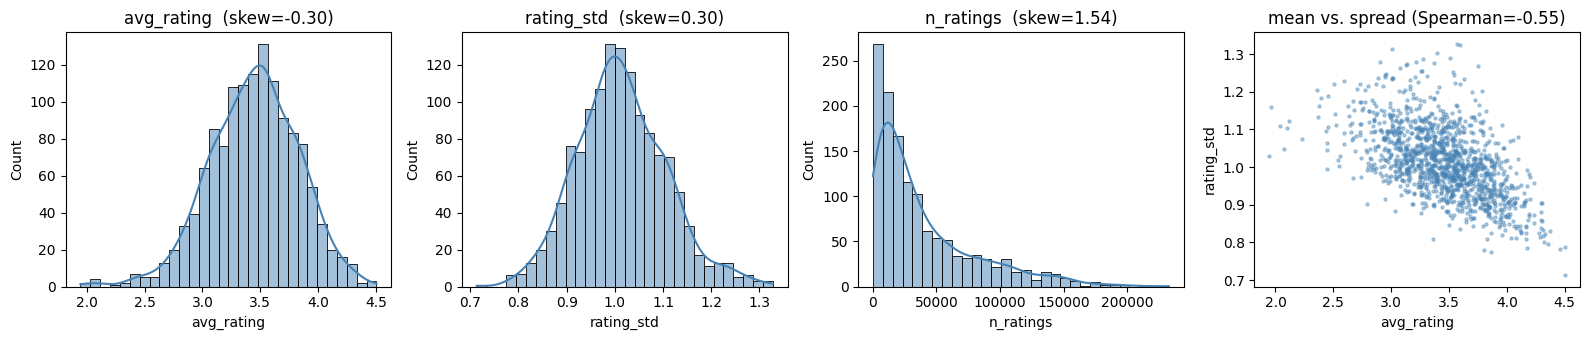

,avg_rating,rating_std,n_ratings
count,1322.000,1322.000,1322.000
mean,3.446,1.014,39000.867
std,0.382,0.092,40003.856
min,1.946,0.713,109.000
25%,3.195,0.952,9665.500
50%,3.460,1.007,24390.500
75%,3.712,1.073,55385.750
max,4.504,1.327,232809.000


In [ ]:
stat_cols = ["avg_rating", "rating_std", "n_ratings"]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, stat_cols):
    sns.histplot(movies[col], bins=30, kde=True, color="steelblue", ax=ax)
    ax.set_title(f"{col}  (skew={movies[col].skew():.2f})")
rho = movies["avg_rating"].corr(movies["rating_std"], method="spearman")
axes[3].scatter(movies["avg_rating"], movies["rating_std"], s=5, alpha=0.4, color="steelblue")
axes[3].set_xlabel("avg_rating")
axes[3].set_ylabel("rating_std")
axes[3].set_title(f"mean vs. spread (Spearman={rho:.2f})")
fig.tight_layout()
plt.show()

**Observations**

- `avg_rating` is almost symmetric (mean 3.45, sd 0.38, slight left tail of badly rated films): **no transform needed** for the target.
- `rating_std` is tightly concentrated around 1.0 (sd 0.09): polarized films differ from typical ones by only a few tenths of a star.
- Better-rated films are **less** polarized (Spearman −0.55): the two targets are not independent.
- `n_ratings` is right-skewed (skew ≈ 1.5): a few blockbusters have >200k ratings, the median film ~24k.

## 4. Numeric features

### 4a. Distributions
For each numeric feature (`year`, `runtime`, `budget`, `revenue`, and the derived `roi = revenue / budget`) three views:
- **Histogram + KDE** (smoothed density curve): the overall shape. A long tail to the right = right skew. The dashed line is the mean, the dotted line the median; the further apart they are, the stronger the skew.
- **Box plot**: median, quartiles, and the points beyond 1.5 × IQR drawn as outliers, so extreme values are visible one by one.
- **Histogram + KDE on a log scale** (not for `year`): if the shape becomes symmetric on the log scale, a log transform is appropriate. If it becomes skewed the other way, log is too strong.

Suspicious money rows from section 2 are excluded here.

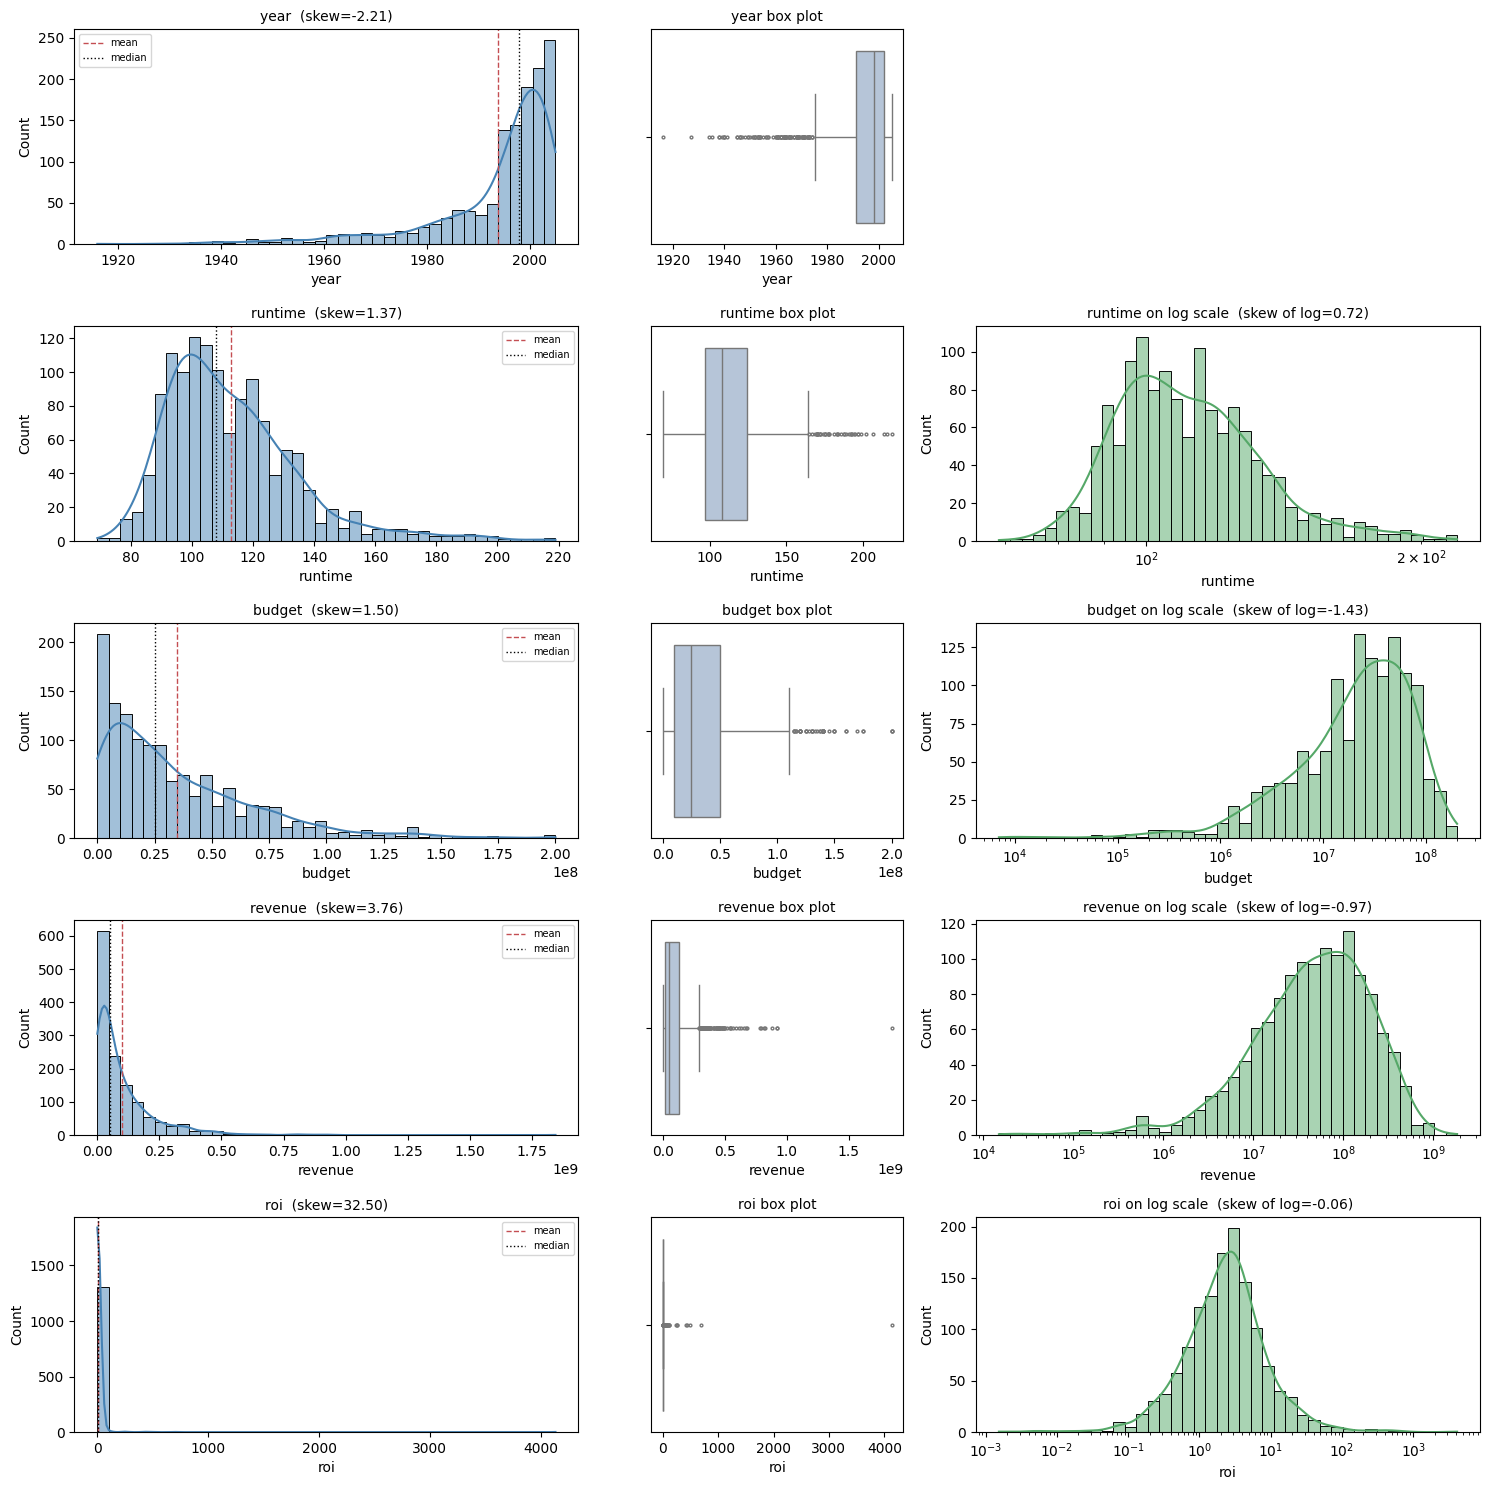

In [7]:
NUMERIC = ["year", "runtime", "budget", "revenue", "roi"]

fig, axes = plt.subplots(len(NUMERIC), 3, figsize=(15, 3 * len(NUMERIC)),
                         gridspec_kw={"width_ratios": [2, 1, 2]})
for row, col in zip(axes, NUMERIC):
    s = movies_ok[col]
    sns.histplot(s, bins=40, kde=True, color="steelblue", ax=row[0])
    row[0].axvline(s.mean(), color="#c44e52", ls="--", lw=1, label="mean")
    row[0].axvline(s.median(), color="black", ls=":", lw=1, label="median")
    row[0].legend(fontsize=7)
    row[0].set_title(f"{col}  (skew={s.skew():.2f})", fontsize=10)
    sns.boxplot(x=s, ax=row[1], color="lightsteelblue", fliersize=2)
    row[1].set_title(f"{col} box plot", fontsize=10)
    if col == "year":
        row[2].axis("off")
        continue
    sns.histplot(s, bins=40, kde=True, log_scale=True, color="#55a868", ax=row[2])
    row[2].set_title(f"{col} on log scale  (skew of log={np.log(s).skew():.2f})", fontsize=10)
fig.tight_layout()
plt.show()

Summary table. **skew**: 0 = symmetric, |skew| > 1 = strong. **kurtosis**: tail heaviness (0 = like a normal distribution). **outliers %**: share of values beyond 1.5 × IQR.

In [8]:
def iqr_outlier_pct(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return 100 * ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean()


pd.DataFrame({
    "skew": [movies_ok[c].skew() for c in NUMERIC],
    "skew_log": [np.log(movies_ok[c]).skew() if c != "year" else np.nan for c in NUMERIC],
    "kurtosis": [movies_ok[c].kurt() for c in NUMERIC],
    "outliers_%": [iqr_outlier_pct(movies_ok[c]) for c in NUMERIC],
    "outliers_%_log": [iqr_outlier_pct(np.log(movies_ok[c])) if c != "year" else np.nan for c in NUMERIC],
}, index=NUMERIC).round(2)

,skew,skew_log,kurtosis,outliers_%,outliers_%_log
year,-2.21,NaN,5.48,8.52,NaN
runtime,1.37,0.72,2.80,3.20,1.67
budget,1.50,-1.43,2.69,3.35,2.74
revenue,3.76,-0.97,28.31,7.99,2.21
roi,32.50,-0.06,1123.42,10.27,3.65


**Observations**

- **`runtime`** is moderately right-skewed (skew 1.4): the body is 95–125 min, and a tail of ~80 films run over 2.5 hours. On the log scale it is only slightly better (0.7). The skew comes from a few long films, not from a multiplicative scale, so **raw runtime (scaled, optionally capped at ~180 min)** is enough.
- **`year`** is **left**-skewed (−2.2): most films are from 1990–2005, with a tail of ~90 older classics (before 1970). As a feature, we will use age (`2005 − year`), which is right-skewed and can take `log1p`.
- **`budget`**: right-skewed (1.5), but on the log scale it is skewed to the *left* (−1.4) because of cheap independent films. Log is too strong; a square root, or log with that caveat, are the options.
- **`revenue`** (skew 3.8, kurtosis 28) and especially **`roi`** (skew 32, kurtosis > 1,000; a few surprise hits earn >1,000× their budget) are extremely skewed. On the log scale both become close to symmetric (roi: −0.06). **Log is clearly needed** for these two.

### 4b. Numeric features vs. rating

Spearman correlations among the numeric features and the rating statistics. Features that are strongly correlated with each other carry overlapping information (for a linear model: unstable coefficients; for clustering: double weight).

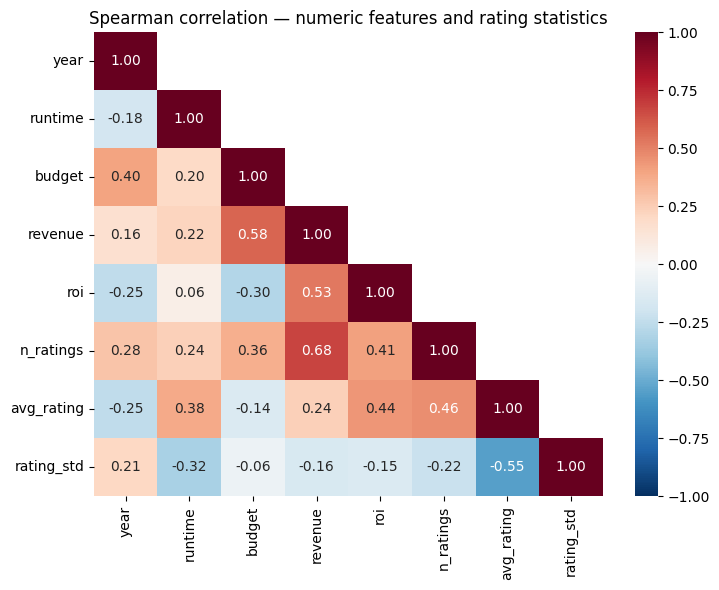

In [10]:
corr_cols = NUMERIC + ["n_ratings", "avg_rating", "rating_std"]
corr = movies_ok[corr_cols].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Spearman correlation — numeric features and rating statistics")
fig.tight_layout()
plt.show()

**Observations**

- **Budget vs. mean rating: a weak negative relationship** (Spearman −0.14). Expensive films are rated slightly *lower*, so money alone doesn't buy quality.
- **ROI is the strongest numeric link** (Spearman 0.44 with `avg_rating`), and **revenue** is moderate (0.24). Both are only known *after* the cinema release, but before the Netflix ratings, so they are allowed (see section 12).
- **Runtime** (0.38) and **year** (−0.25; older films rate higher, because old films still in the catalog are the classics) are the strongest *pre-release* numeric features. Both also go with lower polarization (`rating_std`).
- Redundancy: budget ↔ revenue 0.58, revenue ↔ n_ratings 0.68, budget ↔ year 0.40. Revenue is largely "popularity"; `n_ratings` itself correlates with `avg_rating` at 0.46.

## 5. Genres

A movie can have several genres. Four views:
1. **Frequency** (bar chart): how many movies have each genre. Very rare genres give unreliable one-hot columns.
2. **Genres per movie**: confirms the multi-label structure.
3. **Co-occurrence matrix** (heatmap): how often two genres appear on the same movie. Left: raw counts (diagonal = genre frequency). Right: row-normalised, i.e. *of the movies with the row genre, the share that also have the column genre*. Pairs with high shares carry overlapping information.
4. **Rating per genre** (box plot): whether some genres are rated systematically higher or lower.

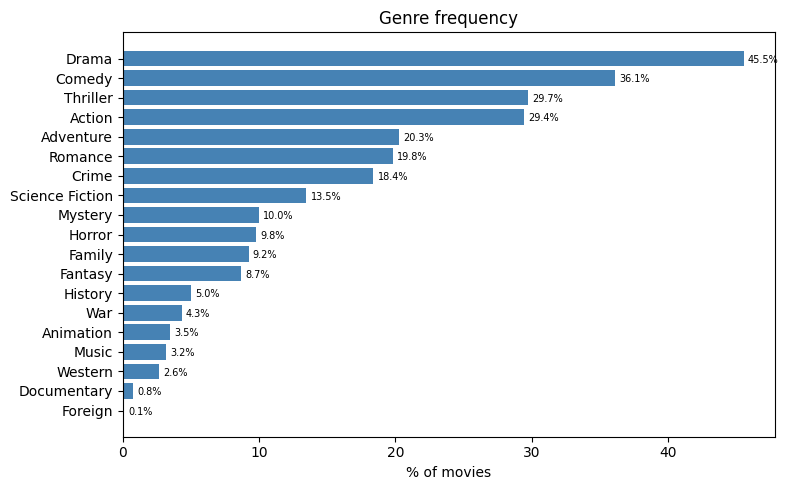

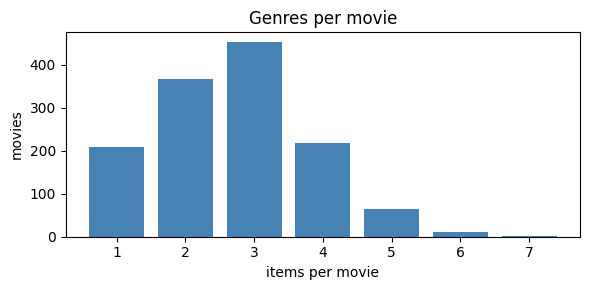

In [11]:
genre_counts = explode_counts(movies["genre_names"])
fig, ax = plt.subplots(figsize=(8, 5))
pct = 100 * genre_counts[::-1] / len(movies)
ax.barh(pct.index, pct.values, color="steelblue")
for y, v in enumerate(pct.values):
    ax.annotate(f"{v:.1f}%", (v, y), xytext=(3, -3), textcoords="offset points", fontsize=7)
ax.set_xlabel("% of movies")
ax.set_title("Genre frequency")
fig.tight_layout()
plt.show()

per_movie_count_bar(movies["genre_names"], "Genres per movie")

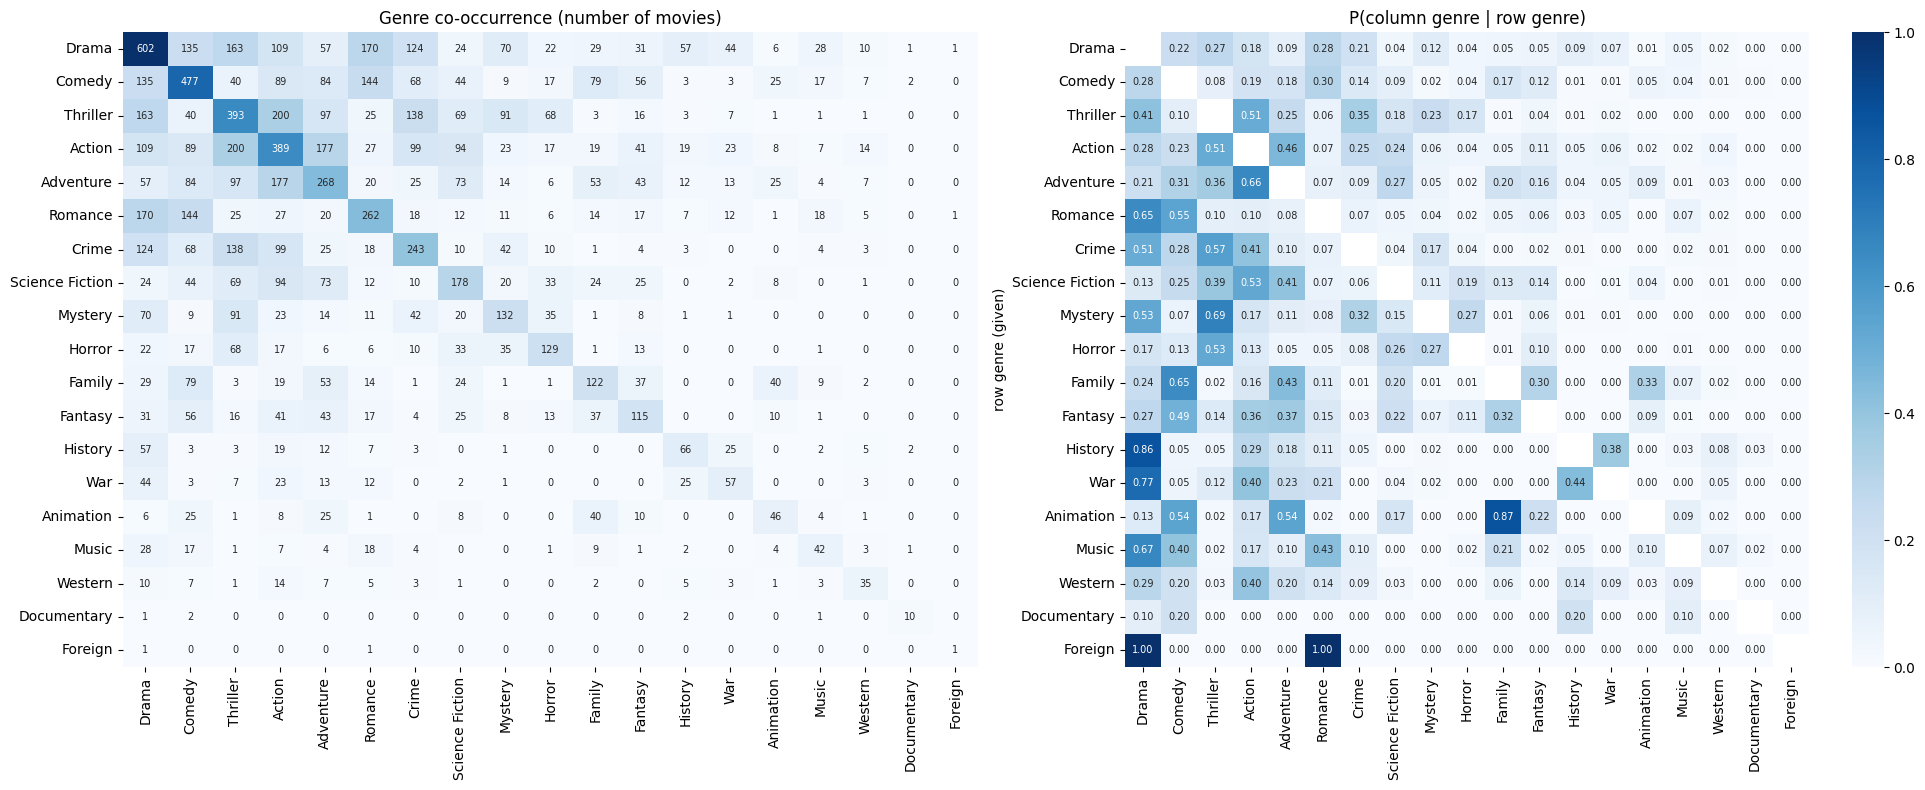

strongest dependencies, P(B | A) with ≥ 10 shared movies:


Animation  Family      0.87
History    Drama       0.86
War        Drama       0.77
Mystery    Thriller    0.69
Music      Drama       0.67
Adventure  Action      0.66
Romance    Drama       0.65
Family     Comedy      0.65
Crime      Thriller    0.57
Romance    Comedy      0.55
dtype: float64

In [12]:
genre_order = list(genre_counts.index)
genre_dummies = pd.get_dummies(movies["genre_names"].explode()).groupby(level=0).max()[genre_order].astype(int)
co = genre_dummies.T @ genre_dummies
co_share = co.div(np.diag(co), axis=0)  # row genre A -> P(column genre B | A)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(co, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False, annot_kws={"fontsize": 7})
axes[0].set_title("Genre co-occurrence (number of movies)")
off_diag = co_share.where(~np.eye(len(co_share), dtype=bool))
sns.heatmap(off_diag, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=axes[1], annot_kws={"fontsize": 7})
axes[1].set_title("P(column genre | row genre)")
axes[1].set_ylabel("row genre (given)")
fig.tight_layout()
plt.show()

pairs = co_share.where(~np.eye(len(co_share), dtype=bool)).stack()
pairs = pairs[co.stack().reindex(pairs.index) >= 10]
print("strongest dependencies, P(B | A) with ≥ 10 shared movies:")
pairs.sort_values(ascending=False).head(10).round(2)

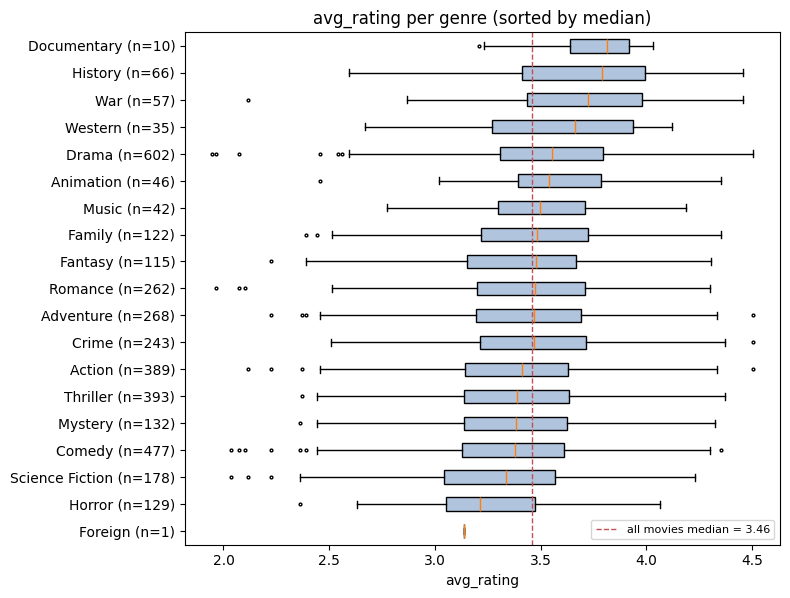

In [13]:
genre_ratings = {
    g: movies.loc[genre_dummies[g] == 1, "avg_rating"].dropna()
    for g in genre_order
}
genre_ratings = dict(sorted(genre_ratings.items(), key=lambda kv: kv[1].median()))
rating_boxplot(genre_ratings, "avg_rating per genre (sorted by median)", ref=movies["avg_rating"].median())

**Observations**

- 19 genres; Drama (46%), Comedy (36%), Thriller and Action (~30%) dominate. **`Foreign` (1 movie) and `Documentary` (10 movies) are too rare** for their own column -> we will drop them.
- Movies have 1–7 genres (median 3): genres are **multi-hot**, so every genre keeps its own column (no reference category to drop).
- Strong dependencies: 87% of Animation films are also Family, 86% of History and 77% of War films are also Drama, 69% of Mystery are Thriller, 66% of Adventure are Action. These pairs carry overlapping information; keep this in mind when reading genre coefficients or cluster profiles.
- Ratings differ by genre: **History, War, Western and Drama** have the highest median (3.55–3.79); **Horror (3.21)** and **Science Fiction (3.34)** the lowest (all-movie median 3.46). Genre is a useful signal for both the mean and the persona clustering (RQ1).

## 6. Production companies

There are over a thousand different companies, so a column per company is not feasible. The usual encoding keeps the **top-X** most frequent companies as one-hot columns and groups the rest into `company_other`. The plots help choose X:
- **Top-30 bar chart**: which studios dominate. It shows that some studios are listed under several names, so these aliases are merged right after it; everything below uses the merged names.
- **Coverage curve**: for each X, the share of movies that have at least one top-X company (blue) and the share of all company mentions covered by the top-X (orange). Choose X where the curve flattens: adding more companies then only adds columns with very few movies each.
- **Size of the X-th company**: the smallest column you would create. A column with fewer than ~20–30 movies is hard to learn from.

unique companies: 1414
companies appearing in only 1 movie: 1007 (71%)


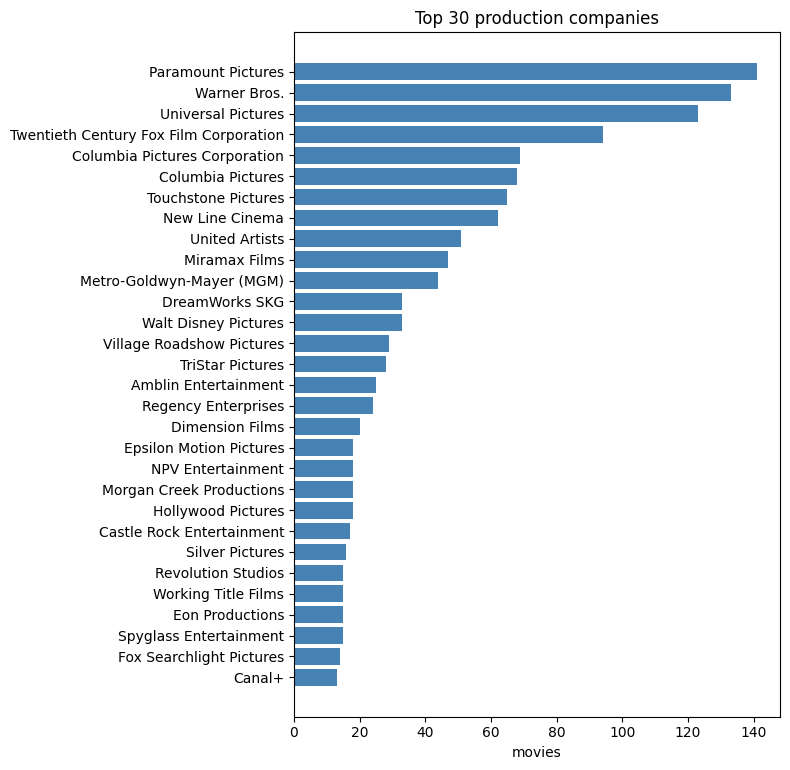

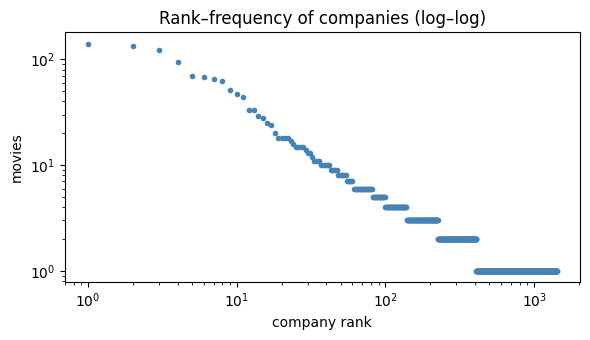

In [ ]:
company_counts = explode_counts(movies["company_names"])
print(f"unique companies: {len(company_counts)}")
print(f"companies appearing in only 1 movie: {(company_counts == 1).sum()} ({100 * (company_counts == 1).mean():.0f}%)")
plot_top_bar(company_counts, 30, "Top 30 production companies")

**Merging name aliases.** Some studios appear under several spellings (e.g. "Columbia Pictures" and "Columbia Pictures Corporation"). Only true aliases of the same company are merged; separate labels of a studio (Fox Searchlight, DreamWorks Animation, …) stay separate.

In [ ]:
COMPANY_ALIASES = {
    "Columbia Pictures Corporation": "Columbia Pictures",
    "Paramount": "Paramount Pictures",
    "Warner Bros. Pictures": "Warner Bros.",
    "Universal Studios": "Universal Pictures",
    "Universal Pictures Corporation": "Universal Pictures",
    "Miramax": "Miramax Films",
    "Walt Disney": "Walt Disney Pictures",
    "Walt Disney Productions": "Walt Disney Pictures",
    "DreamWorks": "DreamWorks SKG",
    "DreamWorks Pictures": "DreamWorks SKG",
    "Polygram Filmed Entertainment": "PolyGram Filmed Entertainment",
    "Lions Gate": "Lions Gate Films",
    "Malpaso Company": "Malpaso Productions",
    "Cruise-Wagner Productions": "Cruise/Wagner Productions",
    "Mandalay Pictures": "Mandalay Entertainment",
    "Zanuck Company, The": "The Zanuck Company",
    "Kennedy/Marshall Company, The": "The Kennedy/Marshall Company",
}
# dict.fromkeys keeps the order and drops a duplicate when a movie listed both aliases
movies["company_names"] = movies["company_names"].map(
    lambda cs: list(dict.fromkeys(COMPANY_ALIASES.get(c, c) for c in cs))
)
company_counts = explode_counts(movies["company_names"])
print(f"unique companies after merging: {len(company_counts)}")
company_counts.head(10)

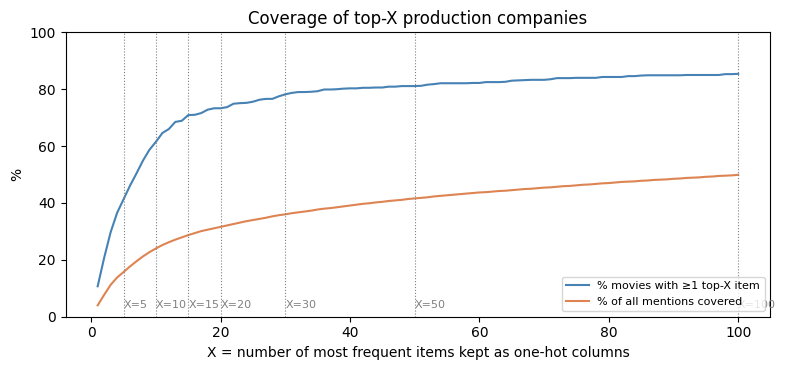

,min_movies_per_kept_item,pct_movies_with_top_item,pct_mentions_covered
X,,,
5,69,41.3,15.7
10,47,61.5,24.0
15,28,70.9,28.7
20,18,73.3,31.6
30,13,78.2,36.0
50,8,81.1,41.6
100,4,85.4,49.9


In [15]:
plot_coverage(movies["company_names"], company_counts, max_x=100, marks=[5, 10, 15, 20, 30, 50, 100],
              title="Coverage of top-X production companies")
print("movies of the X-th company:", {x: int(company_counts.iloc[x - 1]) for x in [10, 15, 20, 30, 50]})

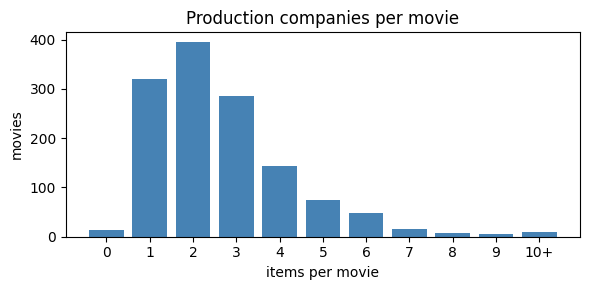

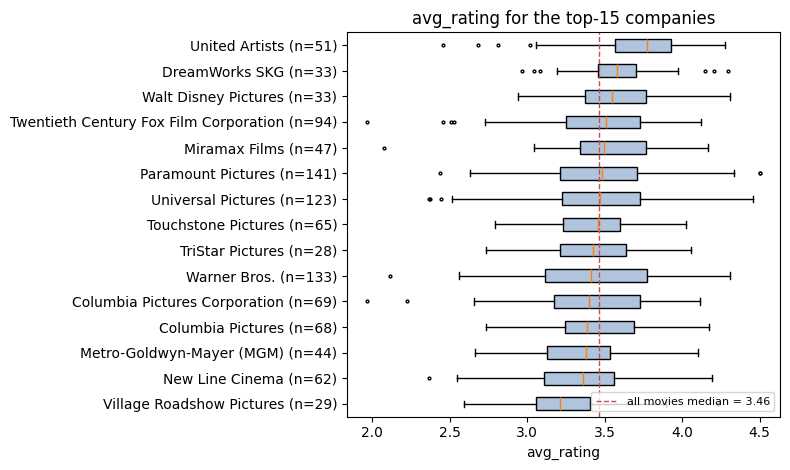

In [16]:
per_movie_count_bar(movies["company_names"], "Production companies per movie")

top_companies = company_counts.index[:15]
company_ratings = {
    c: movies.loc[movies["company_names"].map(lambda cs, c=c: c in cs), "avg_rating"].dropna()
    for c in top_companies
}
company_ratings = dict(sorted(company_ratings.items(), key=lambda kv: kv[1].median()))
rating_boxplot(company_ratings, "avg_rating for the top-15 companies", ref=movies["avg_rating"].median())

**Observations**

- **1,414 company names, 1,397 after merging aliases; 72% appear in only one movie**: a classic long tail, so a column per company is not viable. Merging mainly fixes Columbia (69 + 68 → 136 movies, now tied with Warner Bros. behind Paramount).
- Coverage (merged names):

  | X | smallest kept company (movies) | % movies with ≥1 top-X company |
  |---|---|---|
  | 10 | 44 | 66% |
  | **15** | **25** | **73%** |
  | 20 | 18 | 76% |
  | 30 | 13 | 80% |
  | 50 | 8 | 83% |

  The curve rises steeply to X ≈ 15 and flattens afterwards: going from 15 to 50 companies adds 35 columns but only 10 percentage points of coverage, and each extra column has fewer than 25 movies. **Suggested X ≈ 15** (every kept company has ≥ 25 movies); X = 20 is the upper limit.
- Movies list up to 26 companies (median 2). Median ratings of the big studios range from 3.21 (Village Roadshow) to 3.77 (United Artists), so studio carries some signal.


## 7. Production countries

Same questions as for companies: how concentrated is the distribution, and which X for top-X + `country_other`? The US dominates, so a useful extra view is the rating of US-only films vs. US co-productions vs. non-US films.

unique countries: 42


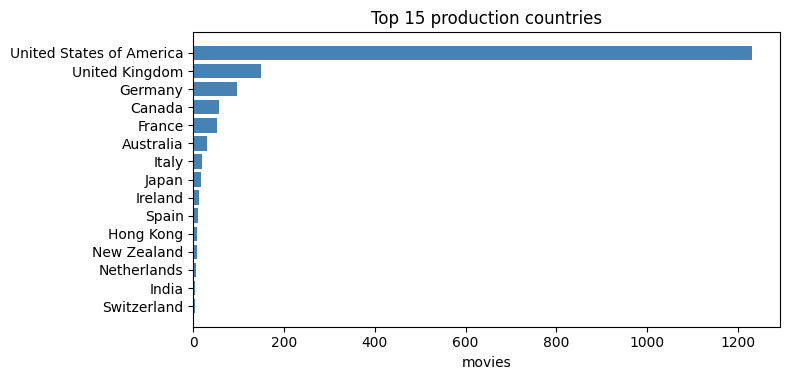

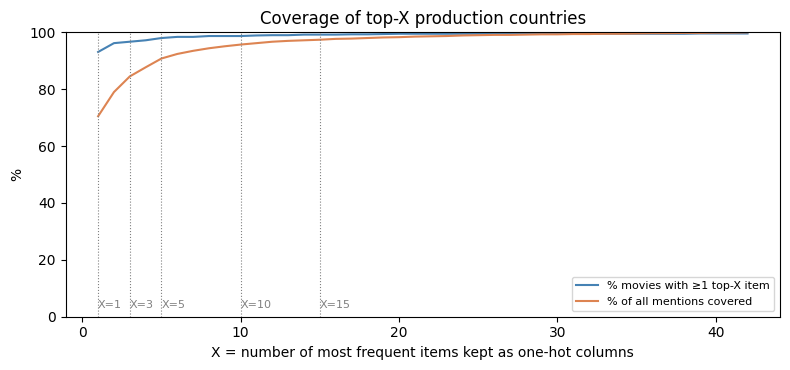

,min_movies_per_kept_item,pct_movies_with_top_item,pct_mentions_covered
X,,,
1,1231,93.1,70.5
3,97,96.7,84.5
5,53,98.0,90.8
10,11,98.7,95.7
15,4,99.2,97.4


In [17]:
country_counts = explode_counts(movies["country_names"])
print(f"unique countries: {len(country_counts)}")
plot_top_bar(country_counts, 15, "Top 15 production countries")
plot_coverage(movies["country_names"], country_counts, max_x=len(country_counts), marks=[1, 3, 5, 10, 15],
              title="Coverage of top-X production countries")

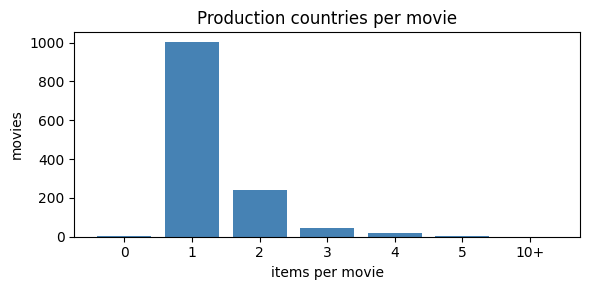

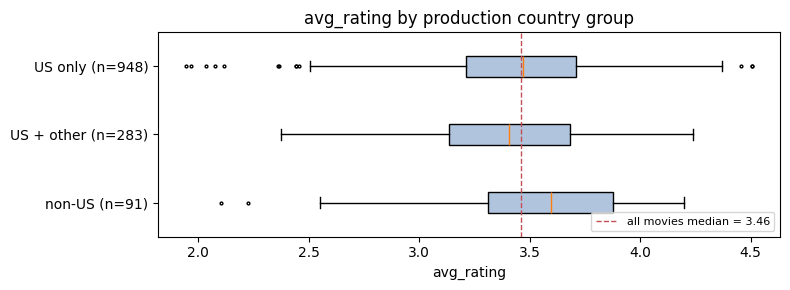

In [18]:
per_movie_count_bar(movies["country_names"], "Production countries per movie")

US = "United States of America"
us_group = movies["country_names"].map(
    lambda cs: "US only" if cs == [US] else ("US + other" if US in cs else "non-US")
)
rating_boxplot(
    {g: movies.loc[us_group == g, "avg_rating"].dropna() for g in ["non-US", "US + other", "US only"]},
    "avg_rating by production country group",
    ref=movies["avg_rating"].median(),
)

**Observations**

- 42 countries, but **the US appears in 93% of movies**; UK (11%), Germany (7%), Canada and France (~4%) follow. Top-3 already covers 97% of movies and top-5 98%. Beyond ~5 countries each column has < 55 movies (the 10th has 11).
- **Suggested encoding:** a few flags instead of top-10: e.g. `us_only` / `us_coproduction` / `non_us`, plus UK / Germany / France / Canada if needed.
- Non-US films have a higher median rating (3.60, n = 91) than US-only films (3.47), and US co-productions are lowest (3.40). A small but clear group effect, probably because foreign films in a US catalog are selected, well-known titles.

## 8. Languages

Two language fields: `original_language` (a single code, e.g. `en`) and `language_names` (all spoken languages in the film). If one value dominates, a simple binary flag (English / not English, one / several languages) may carry all the usable information instead of a one-hot per language.

C:\Users\yael\AppData\Local\Temp\ipykernel_12936\2035232162.py:11: UserWarning: Glyph 26222 (\N{CJK UNIFIED IDEOGRAPH-666E}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\yael\AppData\Local\Temp\ipykernel_12936\2035232162.py:11: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\yael\AppData\Local\Temp\ipykernel_12936\2035232162.py:11: UserWarning: Glyph 35805 (\N{CJK UNIFIED IDEOGRAPH-8BDD}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\yael\AppData\Local\Temp\ipykernel_12936\2035232162.py:11: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\yael\AppData\Local\Temp\ipykernel_12936\2035232162.py:11: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\yael\AppData\Local\Temp\ipykernel_12936\2035232162.py:11: UserWarning: Glyph 35486 (\N{CJK 

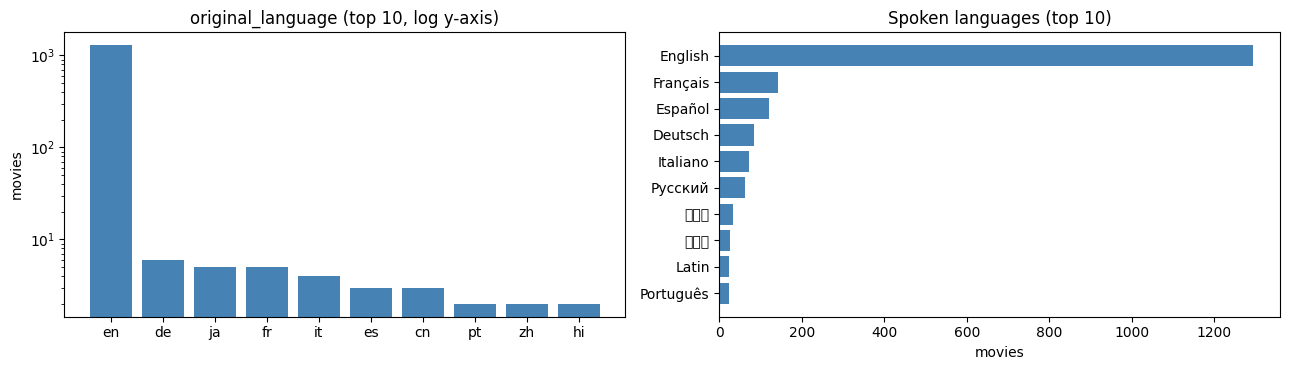

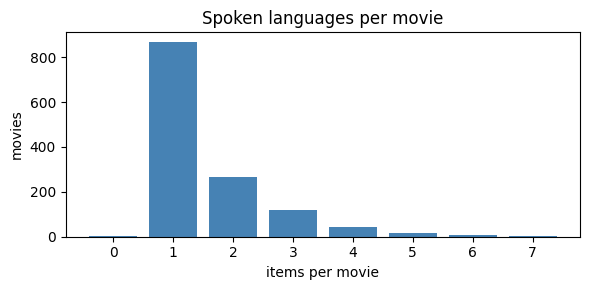

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
orig = movies["original_language"].value_counts().head(10)
axes[0].bar(orig.index, orig.values, color="steelblue")
axes[0].set_yscale("log")
axes[0].set_title("original_language (top 10, log y-axis)")
axes[0].set_ylabel("movies")
spoken = explode_counts(movies["language_names"]).head(10)
axes[1].barh(spoken.index[::-1], spoken.values[::-1], color="steelblue")
axes[1].set_title("Spoken languages (top 10)")
axes[1].set_xlabel("movies")
fig.tight_layout()
plt.show()

per_movie_count_bar(movies["language_names"], "Spoken languages per movie")

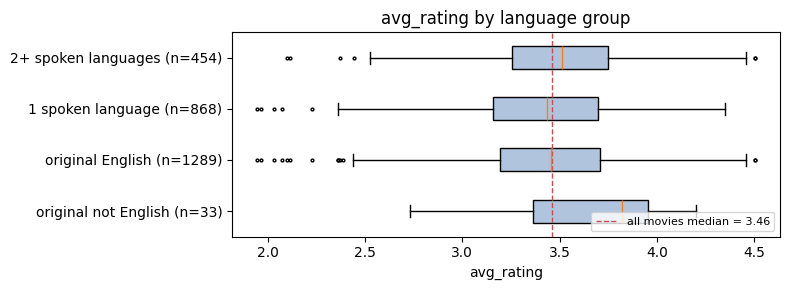

In [20]:
lang_groups = {
    "original not English": movies.loc[movies["original_language"] != "en", "avg_rating"].dropna(),
    "original English": movies.loc[movies["original_language"] == "en", "avg_rating"].dropna(),
    "1 spoken language": movies.loc[movies["language_names"].map(len) <= 1, "avg_rating"].dropna(),
    "2+ spoken languages": movies.loc[movies["language_names"].map(len) > 1, "avg_rating"].dropna(),
}
rating_boxplot(lang_groups, "avg_rating by language group", ref=movies["avg_rating"].median())

**Observations**

- `original_language` is **English for 97.5% of movies** (1,289 of 1,322). The other 33 are spread over ~15 languages with ≤ 6 films each, so a one-hot per language is useless: **a single `lang_en` flag** is enough.
- The 33 non-English films have a much higher median rating (3.82 vs 3.46): again a selection effect (only acclaimed foreign films reach this catalog). The effect is strong but rests on only 33 films.
- 34% of films have 2+ spoken languages; their median rating is only slightly higher (3.51 vs 3.44). **`is_multilingual`** is a weak but cheap flag.

## 9. Directors

Directors are a high-cardinality feature: hundreds of names, most with a single film. The plots show:
- **Films per director**: if most directors appear only once, a one-hot per name (or even a top-X) covers few movies, and a numeric summary is needed instead.
- **Rating per director**: do movies of the same director get similar ratings? If directors differ clearly, "who directed it" is useful information (RQ3, director track record).

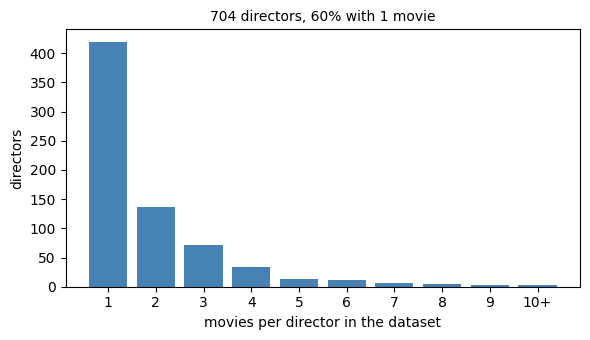

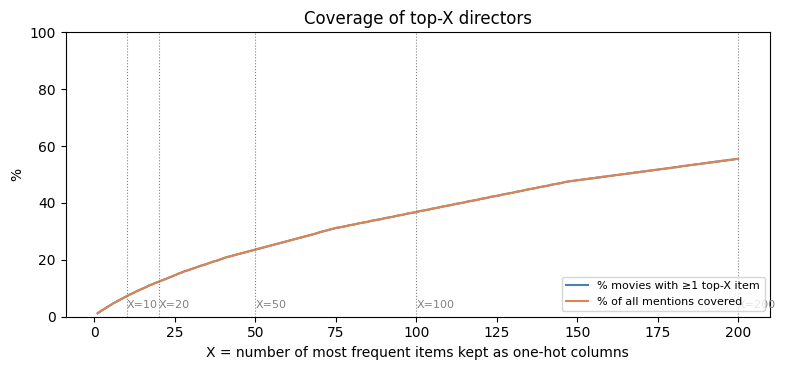

,min_movies_per_kept_item,pct_movies_with_top_item,pct_mentions_covered
X,,,
10,8,7.2,7.2
20,6,12.3,12.3
50,4,23.6,23.6
100,3,36.8,36.8
200,2,55.5,55.5


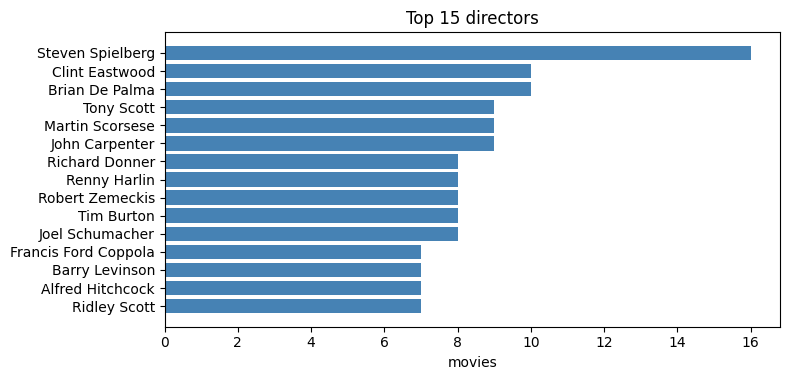

In [21]:
director_counts = movies["director"].value_counts()

fig, ax = plt.subplots(figsize=(6, 3.5))
dist = director_counts.clip(upper=10).value_counts().sort_index()
ax.bar([f"{k}+" if k == 10 else str(k) for k in dist.index], dist.values, color="steelblue")
ax.set_xlabel("movies per director in the dataset")
ax.set_ylabel("directors")
ax.set_title(f"{len(director_counts):,} directors, {100 * (director_counts == 1).mean():.0f}% with 1 movie", fontsize=10)
fig.tight_layout()
plt.show()

plot_coverage(movies["director"].map(lambda d: [d] if isinstance(d, str) else []), director_counts,
              max_x=200, marks=[10, 20, 50, 100, 200], title="Coverage of top-X directors")
plot_top_bar(director_counts, 15, "Top 15 directors")

Box plot of `avg_rating` for the 15 directors with the most movies, and by how many movies the director has in the dataset. The **share of variance explained by director** (η², among directors with ≥ 3 movies) summarises how much ratings differ *between* directors compared with the total variation: 0 = the director tells nothing, 1 = the director fully determines the rating. With only a few movies per director, η² is well above 0 even by chance, so the chance-corrected ε² is the number to read.

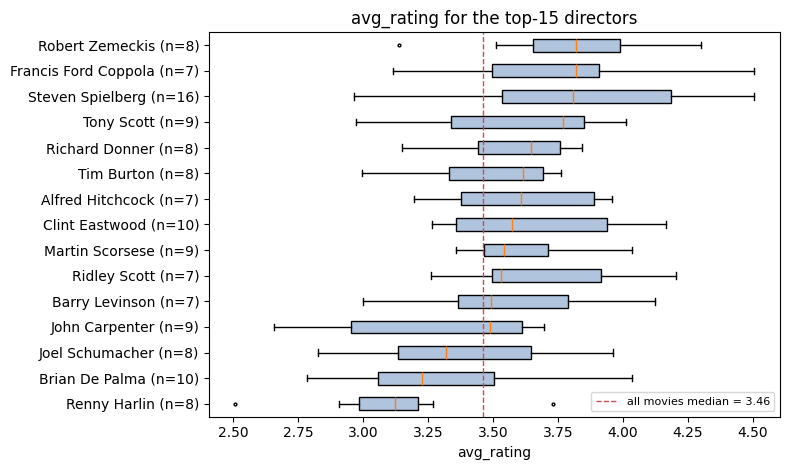

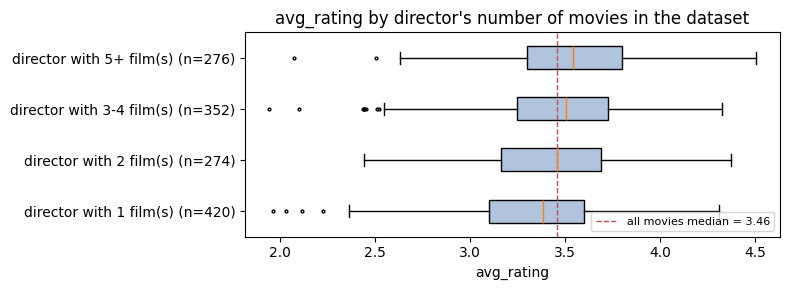

directors with ≥3 movies: 147 (628 movies)
η² = 0.37 | expected by chance = 0.23 | chance-corrected ε² = 0.17


In [22]:
top_directors = director_counts.index[:15]
director_ratings = {d: movies.loc[movies["director"] == d, "avg_rating"].dropna() for d in top_directors}
director_ratings = dict(sorted(director_ratings.items(), key=lambda kv: kv[1].median()))
rating_boxplot(director_ratings, "avg_rating for the top-15 directors", ref=movies["avg_rating"].median())

movies["director_films"] = movies["director"].map(director_counts)
bucket = pd.cut(movies["director_films"], [0, 1, 2, 4, np.inf], labels=["1", "2", "3-4", "5+"])
rating_boxplot(
    {f"director with {b} film(s)": movies.loc[bucket == b, "avg_rating"].dropna() for b in ["1", "2", "3-4", "5+"]},
    "avg_rating by director's number of movies in the dataset",
    ref=movies["avg_rating"].median(),
)

multi = movies[movies["director_films"] >= 3].dropna(subset=["avg_rating"])
k, n = multi["director"].nunique(), len(multi)
group_means = multi.groupby("director")["avg_rating"].transform("mean")
ss_total = ((multi["avg_rating"] - multi["avg_rating"].mean()) ** 2).sum()
ss_between = ((group_means - multi["avg_rating"].mean()) ** 2).sum()
eta2 = ss_between / ss_total
# with few movies per director, eta² is inflated by chance: (k-1)/(n-1) is its expected value if directors had no effect
eps2 = (ss_between - (k - 1) * (ss_total - ss_between) / (n - k)) / ss_total
print(f"directors with ≥3 movies: {k} ({n} movies)")
print(f"η² = {eta2:.2f} | expected by chance = {(k - 1) / (n - 1):.2f} | chance-corrected ε² = {eps2:.2f}")

### Director track record

A numeric way to use "who directed it" that also works for directors with few films: the **track record** = mean `avg_rating` of the director's *other* movies, shrunk toward the overall mean:

$$\text{track record} = \frac{\text{sum of ratings of the other films} + m \cdot \text{global mean}}{\text{number of other films} + m}, \quad m = 3$$

- *Other* films only (leave-one-out): the movie's own rating must not be part of its feature.
- **Shrinkage** (m = 3): a director with one other film gets a score 1/4 of the way from the global mean toward that film's rating, not all the way, so one lucky film can't produce an extreme score. With many films the score approaches their real average. Directors with no other film get the global mean.
- **Earlier films only** variant: uses only films released in earlier years, i.e. exactly what would be known when a new film comes out (cold start).

The same helper is reused for actors in section 10.

In [23]:
GLOBAL_MEAN = movies["avg_rating"].mean()
SHRINK = 3


def track_record(pairs, shrink=SHRINK, prior_only=False):
    """pairs: one row per (movie, person) with avg_rating and year.
    Returns (shrunk mean avg_rating of the person's other films, number of those films) per row."""
    if prior_only:
        by_year = pairs.groupby(["person", "year"])["avg_rating"].agg(["sum", "count"])
        # cumulative totals up to the previous year = films released strictly earlier
        earlier = by_year.groupby(level=0).cumsum() - by_year
        j = pairs.join(earlier, on=["person", "year"])
        other_sum, other_n = j["sum"], j["count"]
    else:
        totals = pairs.groupby("person")["avg_rating"].agg(["sum", "count"])
        j = pairs.join(totals, on="person")
        other_sum, other_n = j["sum"] - j["avg_rating"], j["count"] - 1
    return (other_sum + shrink * GLOBAL_MEAN) / (other_n + shrink), other_n


director_pairs = movies[["netflix_movie_id", "director", "avg_rating", "year"]].rename(columns={"director": "person"})
director_pairs = director_pairs.dropna(subset=["person"])
movies["director_track_record"] = track_record(director_pairs)[0]
movies["director_track_record_prior"] = track_record(director_pairs, prior_only=True)[0]

pd.DataFrame({
    target: [movies[c].corr(movies[target], method="spearman")
             for c in ["director_films", "director_track_record", "director_track_record_prior"]]
    for target in ["avg_rating", "rating_std"]
}, index=["director film count", "director track record", "director track record (earlier films only)"]).round(3)

,avg_rating,rating_std
director film count,0.168,-0.206
director track record,0.220,-0.196
director track record (earlier films only),0.177,-0.172


**Observations**

- **60% of directors appear in only one movie** of the dataset. Even the top-200 directors cover only ~55% of movies (top-10: 7%), so **one-hot or top-X encoding of director names is not viable**; the director must be summarised as a number.
- The most frequent are well-known names: Spielberg (16 films), De Palma and Eastwood (10).
- **Experience goes with rating:** median `avg_rating` rises from 3.39 (director with 1 film in the dataset) to 3.46 (2), 3.51 (3–4) and 3.55 (5+). The steps shrink as counts grow, so `log1p(film count)` fits the shape.
- **Director identity matters beyond chance:** among directors with ≥ 3 movies η² = 0.37, but ~0.23 of that is what chance alone would give, so the chance-corrected ε² ≈ 0.17: a real but moderate effect.
- **Track record vs. film count** (Spearman with `avg_rating`): the full track record is best (0.22), but the earlier-films-only version (cold-start safe) is 0.18, barely above plain film count (0.17). For cold start, `log1p(film count)` is a simpler, almost equally good choice. All three go with *lower* polarization (≈ −0.2).

## 10. Actors — whether and how to use them

**Billing order.** The cast of a film is credited in a fixed order (TMDB field `order`: 0 = lead actor, 1 = second lead, …; supporting roles and extras last). `cast_names` is stored in this order (`cast_names[0..2]` is identical to `actor_1..3` for every movie), so **"the first k actors" = the k most important roles**. The leads are who audiences pick a film by; the full cast averages ~18 names and goes up to 213, mostly small roles.

**Why not one-hot?** Like directors, most actors appear in a single film (below), so names must be turned into a numeric **score per movie**: compute a value per actor, then average over the movie's first k actors. Three candidate scores:

| score | meaning | question it answers |
|---|---|---|
| `experience` | number of *other* films of the actor in the dataset | are casts of well-known, busy actors rated differently? |
| `exposure` | log of the average `n_ratings` of the actor's other films | **popularity**: do actors from widely watched films pull the rating up? |
| `track_record` | shrunk mean `avg_rating` of the actor's other films (same formula as for directors) | **quality**: are actors who appear in well-rated films rated well again? |

The analysis picks the score type and k (how many billed actors to use).

### 10a. Cast structure

Left: cast size per movie. Middle: for each billing position, the share of movies where that actor also appears in another film of the dataset (only then can a score be computed from other films). Right: how many movies each actor appears in, for lead actors and for the full cast.

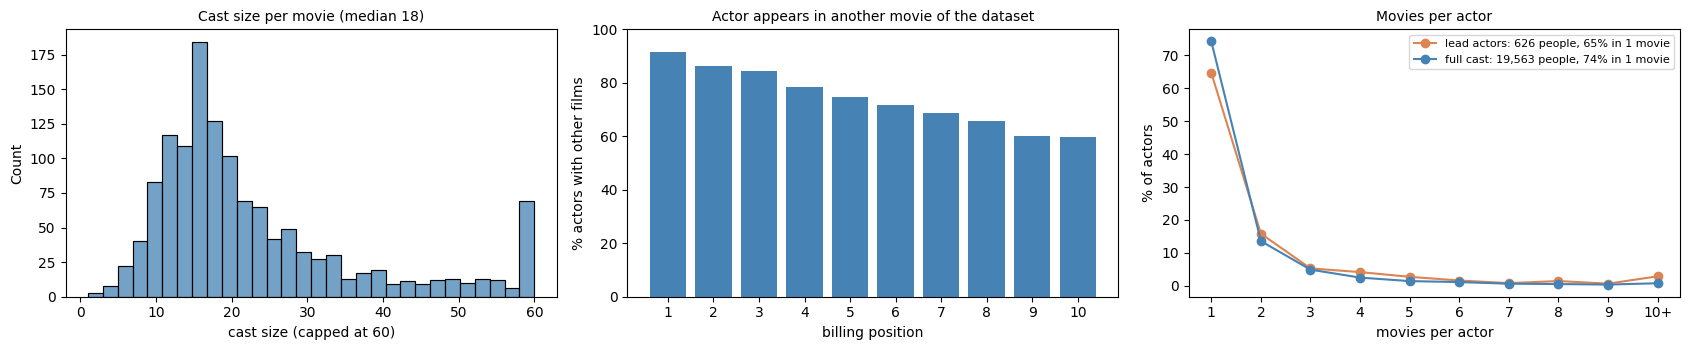

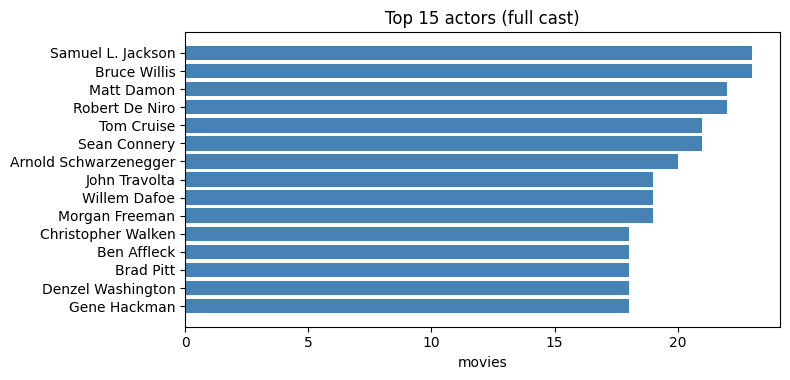

In [24]:
actor_counts = explode_counts(movies["cast_names"])
lead_counts = movies["actor_1"].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(17, 3.6))
sns.histplot(movies["cast_names"].map(len).clip(upper=60), bins=30, color="steelblue", ax=axes[0])
axes[0].set_xlabel("cast size (capped at 60)")
axes[0].set_title(f"Cast size per movie (median {movies['cast_names'].map(len).median():.0f})", fontsize=10)

positions = range(1, 11)
known = [
    100 * movies["cast_names"].map(lambda c, i=i: len(c) >= i and actor_counts[c[i - 1]] > 1).sum()
    / (movies["cast_names"].map(len) >= i).sum()
    for i in positions
]
axes[1].bar([str(i) for i in positions], known, color="steelblue")
axes[1].set_xlabel("billing position")
axes[1].set_ylabel("% actors with other films")
axes[1].set_ylim(0, 100)
axes[1].set_title("Actor appears in another movie of the dataset", fontsize=10)

for name, counts, color in [("lead actors", lead_counts, "#dd8452"), ("full cast", actor_counts, "steelblue")]:
    dist = counts.clip(upper=10).value_counts(normalize=True).sort_index() * 100
    axes[2].plot([f"{k}+" if k == 10 else str(k) for k in dist.index], dist.values, marker="o", color=color,
                 label=f"{name}: {len(counts):,} people, {100 * (counts == 1).mean():.0f}% in 1 movie")
axes[2].set_xlabel("movies per actor")
axes[2].set_ylabel("% of actors")
axes[2].legend(fontsize=8)
axes[2].set_title("Movies per actor", fontsize=10)
fig.tight_layout()
plt.show()

plot_top_bar(actor_counts, 15, "Top 15 actors (full cast)")

### 10b. Which score, and how many billed actors?

`actor_scores(k)` computes the three scores for every movie from its first k billed actors. The plot shows the Spearman correlation of each score with `avg_rating` (left) and `rating_std` (right) for k = 1 … 10. The dotted line is the track record from **earlier films only**. Higher |ρ| = more useful; the curve shape shows where adding more actors stops helping.

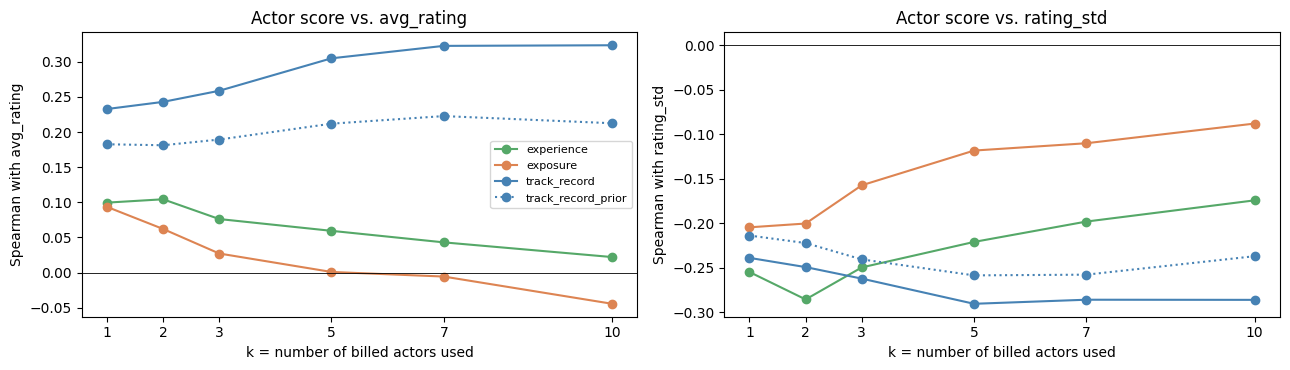

score,experience,exposure,track_record,track_record_prior
k,,,,
1,0.099,0.093,0.233,0.183
2,0.104,0.062,0.243,0.181
3,0.076,0.027,0.259,0.189
5,0.059,0.001,0.305,0.212
7,0.043,-0.006,0.323,0.223
10,0.022,-0.045,0.324,0.212


In [ ]:
def actor_scores(k, prior_only=False):
    """Per-movie mean of experience / exposure / track_record over the first k billed actors."""
    pairs = movies[["netflix_movie_id", "cast_names", "avg_rating", "n_ratings", "year"]].copy()
    pairs["person"] = pairs["cast_names"].map(lambda c: c[:k])
    pairs = pairs.explode("person").dropna(subset=["person"]).drop(columns="cast_names").reset_index(drop=True)
    pairs["track_record"], other_n = track_record(pairs, prior_only=prior_only)
    if prior_only:
        return pairs.groupby("netflix_movie_id")["track_record"].mean()
    pop = pairs.groupby("person")["n_ratings"].transform("sum") - pairs["n_ratings"]
    pairs["experience"] = other_n
    # actors without other films get exposure 0, like experience 0
    pairs["exposure"] = np.where(other_n > 0, np.log1p(pop / other_n.clip(lower=1)), 0)
    return pairs.groupby("netflix_movie_id")[["experience", "exposure", "track_record"]].mean()


K_VALUES = [1, 2, 3, 5, 7, 10]
target = movies.set_index("netflix_movie_id")[["avg_rating", "rating_std"]]
rows = []
for k in K_VALUES:
    scores = actor_scores(k).join(actor_scores(k, prior_only=True).rename("track_record_prior"))
    scores = scores.join(target)
    for s in ["experience", "exposure", "track_record", "track_record_prior"]:
        rows.append({"k": k, "score": s,
                     "avg_rating": scores[s].corr(scores["avg_rating"], method="spearman"),
                     "rating_std": scores[s].corr(scores["rating_std"], method="spearman")})
k_table = pd.DataFrame(rows)

styles = {"experience": ("#55a868", "-"), "exposure": ("#dd8452", "-"),
          "track_record": ("steelblue", "-"), "track_record_prior": ("steelblue", ":")}
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, t in zip(axes, ["avg_rating", "rating_std"]):
    for s, (color, ls) in styles.items():
        d = k_table[k_table["score"] == s]
        ax.plot(d["k"], d[t], marker="o", color=color, ls=ls, label=s)
    ax.axhline(0, color="black", lw=0.6)
    ax.set_xticks(K_VALUES)
    ax.set_xlabel("k = number of billed actors used")
    ax.set_ylabel(f"Spearman with {t}")
    ax.set_title(f"Actor score vs. {t}")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

### 10c. The cast track record in detail (k = 3)

Left: the top-3 cast track record against `avg_rating`, with the binned trend line. Right: cast vs. director track record. If the two were strongly correlated, one of them would be redundant.

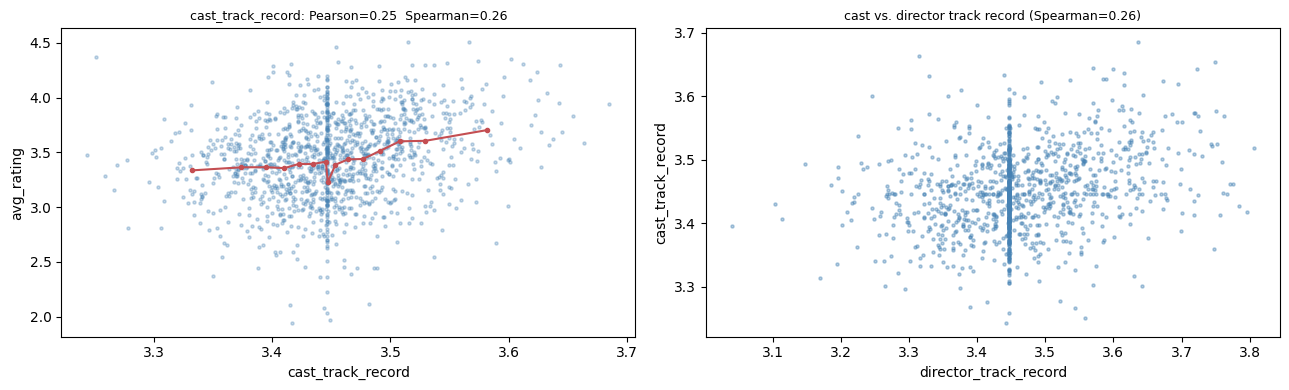

In [26]:
CAST_K = 3
cast = actor_scores(CAST_K).add_prefix("cast_").join(
    actor_scores(CAST_K, prior_only=True).rename("cast_track_record_prior")
)
for c in cast.columns:
    movies[c] = movies["netflix_movie_id"].map(cast[c])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_vs_rating(movies, "cast_track_record", "avg_rating", axes[0])
axes[1].scatter(movies["director_track_record"], movies["cast_track_record"], s=5, alpha=0.4, color="steelblue")
rho = movies["director_track_record"].corr(movies["cast_track_record"], method="spearman")
axes[1].set_xlabel("director_track_record")
axes[1].set_ylabel("cast_track_record")
axes[1].set_title(f"cast vs. director track record (Spearman={rho:.2f})", fontsize=9)
fig.tight_layout()
plt.show()

**Observations**

- **Names can't be used directly:** 19,563 actors, 74% of them in one movie only (65% of the 626 lead actors). But the leading roles are mostly "known" actors: the lead appears in another movie of the dataset in 91% of films, position 3 in 84%, position 10 only in 60%. A score based on other films is available for almost every movie when using the first few billed actors.
- **Popularity doesn't predict the mean rating.** `exposure` (how widely watched the actor's other films are) is ≈ 0 for k ≥ 3, and `experience` (how many films) is at most 0.10. Both relate to **polarization** instead: movies with busy, well-known casts are rated more consistently (`experience` vs `rating_std` ≈ −0.25).
- **Quality track record is the useful actor signal:** 0.26 for the top-3 billed actors, rising to 0.31 (k = 5) and 0.32 (k = 7–10), then flat. Earlier-films-only: 0.19 (k = 3) to 0.22 (k = 7).
- Cast and director track records overlap only weakly (Spearman 0.26), so they carry **different** information and both are worth keeping.

**Recommendation — how to use actors**
1. Drop per-slot features (`actor_1..3` names or counts): the slots are arbitrary and add nothing over one cast-level score.
2. Use **`cast_track_record` over the first 3–5 billed actors** (k = 5 is slightly stronger; beyond 5 the gain is negligible and supporting roles are noisy), with shrinkage m = 3.
3. Optionally add **`cast_experience`** (mean number of other films, `log1p`) as a polarization feature for RQ2.
4. **Leakage rule:** the track record uses the ratings of *other* movies. In modelling, compute it **only from training movies** (inside each cross-validation fold). For the cold-start setting, use the **earlier-films-only** version. Computed on all movies, as in this EDA, it would slightly overstate its value.

## 11. Non-numeric features vs. rating — summary

Section 4 related each numeric feature to the rating. This section does the same for all non-numeric features at once, encoded the way sections 5–8 suggest: 19 genres, the top-15 companies + `company_other`, country groups (US only / US co-production / non-US) + the next 4 countries, `lang_en` and `is_multilingual`. The 8 suspicious-money movies are excluded, as in section 4.

In [27]:
ind = {}
for g in genre_order:
    ind[("genre", g)] = genre_dummies[g]
top_company_set = set(company_counts.index[:15])
for c in company_counts.index[:15]:
    ind[("company", c)] = movies["company_names"].map(lambda cs, c=c: c in cs)
ind[("company", "other (not top-15)")] = movies["company_names"].map(lambda cs: any(c not in top_company_set for c in cs))
for g in ["US only", "US + other", "non-US"]:
    ind[("country", g)] = us_group == g
for c in ["United Kingdom", "Germany", "France", "Canada"]:
    ind[("country", c)] = movies["country_names"].map(lambda cs, c=c: c in cs)
ind[("language", "original English")] = movies["original_language"] == "en"
ind[("language", "2+ spoken languages")] = movies["language_names"].map(len) > 1

indicators = pd.DataFrame(ind).astype(int)[~suspect]
rated = movies.loc[~suspect]
print(f"{indicators.shape[1]} indicator columns, {len(indicators)} movies")

44 indicator columns, 1314 movies


### 11a. Effect of each indicator on the rating

**Forest plot**: each row is one indicator. The dot is the **difference in mean rating** between movies with and without it (in stars for `avg_rating`); the line is its 95% confidence interval. A line that crosses 0 means the difference could be chance. Rare indicators (small n) get wide lines. Chosen over plain correlation bars because the effect is in interpretable units *and* its reliability is visible. Indicators with fewer than 5 movies are left out.

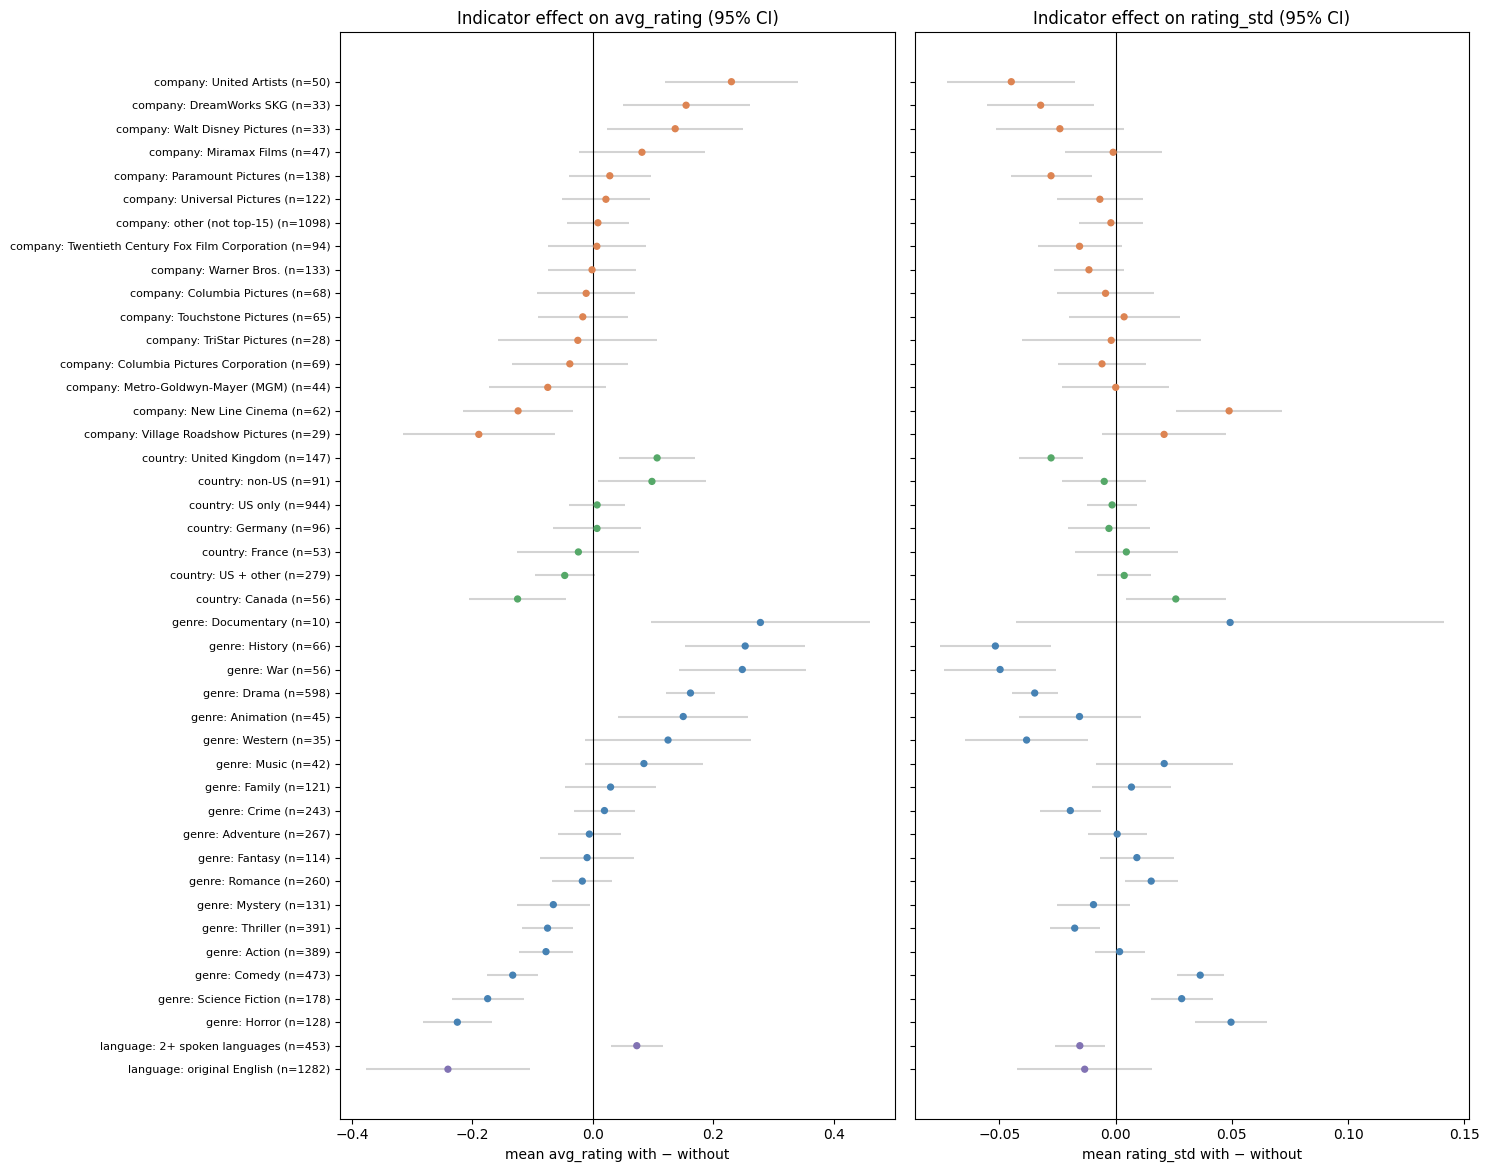

In [28]:
def indicator_effects(indicators, y):
    rows = []
    for (family, name), col in indicators.items():
        y1, y0 = y[col == 1], y[col == 0]
        if len(y1) < 5:
            continue
        diff = y1.mean() - y0.mean()
        se = np.sqrt(y1.var() / len(y1) + y0.var() / len(y0))
        rows.append({"family": family, "name": name, "n": len(y1), "diff": diff, "ci": 1.96 * se})
    return pd.DataFrame(rows)


FAMILY_COLORS = {"genre": "steelblue", "company": "#dd8452", "country": "#55a868", "language": "#8172b3"}
effects = {t: indicator_effects(indicators, rated[t]) for t in ["avg_rating", "rating_std"]}
order = effects["avg_rating"].sort_values(["family", "diff"], ascending=[False, True]).reset_index(drop=True)
labels = [f"{r.family}: {r.name} (n={r.n})" for r in order.itertuples()]

fig, axes = plt.subplots(1, 2, figsize=(15, 0.24 * len(order) + 1.5), sharey=True)
for ax, t in zip(axes, ["avg_rating", "rating_std"]):
    e = effects[t].set_index(["family", "name"]).loc[list(zip(order["family"], order["name"]))]
    ax.errorbar(e["diff"], range(len(e)), xerr=e["ci"], fmt="none", ecolor="lightgray", lw=1.5)
    ax.scatter(e["diff"], range(len(e)), c=[FAMILY_COLORS[f] for f in order["family"]], s=18, zorder=3)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel(f"mean {t} with − without")
    ax.set_title(f"Indicator effect on {t} (95% CI)")
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels(labels, fontsize=8)
fig.tight_layout()
plt.show()

### 11b. How much does each feature group explain?

**Adjusted R²** of a linear regression of `avg_rating` on one feature group at a time: the share of rating differences that group explains on its own, corrected for the number of columns (a group with many columns doesn't get credit just for its size). Numeric groups use the transforms suggested in section 4; the people scores are the track records from sections 9–10.

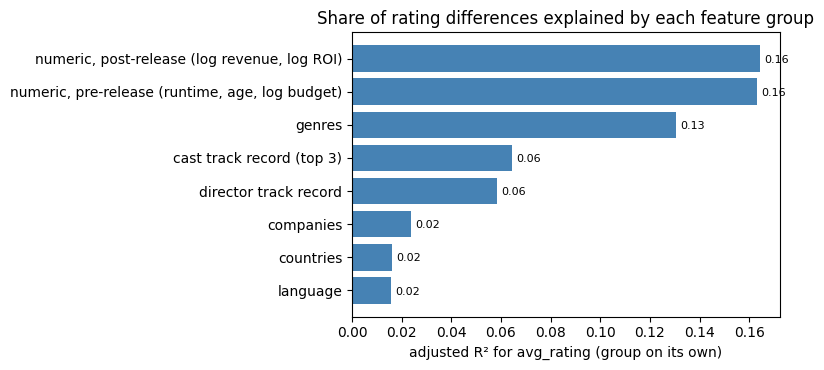

In [29]:
def adjusted_r2(X, y):
    X1 = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(X1, y, rcond=None)
    r2 = 1 - ((y - X1 @ beta) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    p = np.linalg.matrix_rank(X1) - 1
    return 1 - (1 - r2) * (len(y) - 1) / (len(y) - p - 1)


groups = {
    "genres": indicators["genre"],
    "companies": indicators["company"],
    "countries": indicators["country"],
    "language": indicators["language"],
    "numeric, pre-release (runtime, age, log budget)":
        pd.DataFrame({"runtime": rated["runtime"], "age": np.log1p(2005 - rated["year"]),
                      "budget": np.log(rated["budget"])}),
    "numeric, post-release (log revenue, log ROI)":
        pd.DataFrame({"revenue": np.log(rated["revenue"]), "roi": np.log(rated["roi"])}),
    "director track record": rated[["director_track_record"]],
    "cast track record (top 3)": rated[["cast_track_record"]],
}
y = rated["avg_rating"].to_numpy()
group_r2 = pd.Series({name: adjusted_r2(X.to_numpy(dtype=float), y) for name, X in groups.items()}).sort_values()

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(group_r2.index, group_r2.values, color="steelblue")
for i, v in enumerate(group_r2.values):
    ax.annotate(f"{v:.2f}", (v, i), xytext=(3, -3), textcoords="offset points", fontsize=8)
ax.set_xlabel("adjusted R² for avg_rating (group on its own)")
ax.set_title("Share of rating differences explained by each feature group")
fig.tight_layout()
plt.show()

### 11c. All features ranked

One ranking of every feature's Spearman correlation with `avg_rating`: numeric features (section 4), people scores (sections 9–10) and all indicators, top 25 by absolute value. Blue bars point up (higher rating), red bars down; the colour of the label marks the feature type.

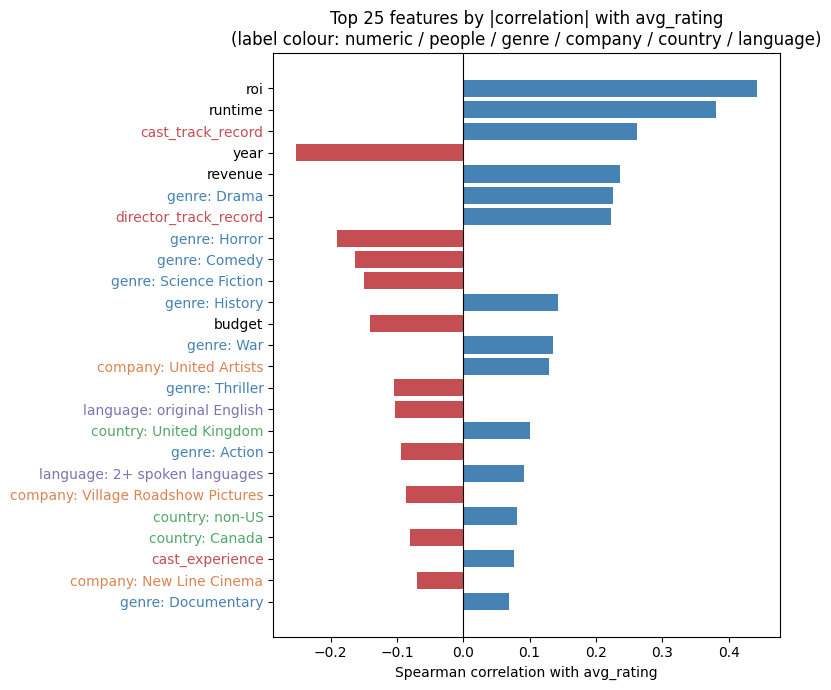

In [30]:
numeric_like = {
    "year": rated["year"], "runtime": rated["runtime"], "budget": rated["budget"],
    "revenue": rated["revenue"], "roi": rated["roi"],
    "director_track_record": rated["director_track_record"],
    "cast_track_record": rated["cast_track_record"],
    "cast_experience": rated["cast_experience"], "cast_exposure": rated["cast_exposure"],
}
TYPE_COLORS = {"numeric": "black", "people": "#c44e52", **FAMILY_COLORS}
ranking = []
for name, s in numeric_like.items():
    kind = "people" if name.startswith(("cast", "director")) else "numeric"
    ranking.append((name, kind, s.corr(rated["avg_rating"], method="spearman")))
for (family, name), col in indicators.items():
    if col.sum() >= 5:
        ranking.append((f"{family}: {name}", family, col.corr(rated["avg_rating"], method="spearman")))
ranking = pd.DataFrame(ranking, columns=["feature", "type", "spearman"])
top = ranking.reindex(ranking["spearman"].abs().sort_values(ascending=False).index).head(25)[::-1]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top["feature"], top["spearman"], color=["steelblue" if v > 0 else "#c44e52" for v in top["spearman"]])
for tick, kind in zip(ax.get_yticklabels(), top["type"]):
    tick.set_color(TYPE_COLORS[kind])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Spearman correlation with avg_rating")
ax.set_title("Top 25 features by |correlation| with avg_rating\n(label colour: numeric / people / genre / company / country / language)")
fig.tight_layout()
plt.show()

**Observations**

- **Genres carry most of the non-numeric signal.** On their own they explain ~13% of the variance in mean rating (adjusted R²), close to the numeric groups (pre-release runtime/age/budget 16%, post-release revenue/ROI 16%). Each people track record explains ~6%. Companies (2%), countries and language (1.6% each) add little by themselves.
- **20 of 43 indicators have a difference in `avg_rating` clearly different from 0.** Largest: History (+0.25 stars), War (+0.25), United Artists (+0.23), Drama (+0.16) vs Horror (−0.23), Village Roadshow (−0.19), Science Fiction (−0.17), Comedy (−0.13). English-language originals are −0.24 below the rest, but the interval is wide (only 33 non-English films).
- **Polarization (`rating_std`) mirrors the mean:** genres rated higher (History, War, Western, Drama) are also rated more consistently, and Horror, Comedy and Science Fiction are more polarizing. The effects are small in absolute terms (±0.05 on a std of ~1.0).
- **Overall ranking** (Spearman with `avg_rating`): ROI 0.44, runtime 0.38, **cast track record 0.26**, year −0.25, revenue 0.24, Drama 0.23, **director track record 0.22**, then Horror / Comedy / Science Fiction. Popularity-type people scores (`cast_experience`) are near the bottom. No single feature dominates, so the model must combine them.

## 12. Summary and encoding / transformation decisions

**Scope decision:** the model predicts Netflix ratings for movies that have already been released in cinemas, so post-release box-office features (revenue, ROI) are allowed: theatrical success is known before the Netflix ratings. (For 2004–2005 films the two periods can overlap.)

| Feature | Finding | Decision |
|---|---|---|
| budget / revenue (8 rows) | impossible values (< \$1,000) | drop these movies in preprocessing |
| `runtime` | moderate right skew from a few long films; + with rating (0.38) | keep raw + scaling, optionally cap at ~180 min |
| `year` | left skew, tail of old classics; older → higher rating (−0.25) | `movie_age = log1p(2005 − year)` (log1p because 2005 films have age 0) |
| ROI | extreme skew, symmetric on log scale; strongest numeric link (0.44) | `log(roi)` |
| `budget`, `revenue` | log ROI = log revenue − log budget, so ROI already combines both; adding budget to runtime + age + log ROI does not raise adjusted R² (0.286 → 0.285) | drop both |
| genres | 19, multi-hot; Foreign / Documentary rare; explain ~13% alone | multi-hot (a column per genre, no reference dropped), drop Foreign & Documentary |
| companies | 1,397 after merging aliases, long tail; explain ~2% | merge aliases, **top-15** + `company_other` |
| countries | US in 93%; explain ~2% | `us_only` / `us_coproduction` / `non_us` (drop one as reference for a linear model); optional UK / Canada flags |
| language | English 97.5%; multilingual films slightly higher | `lang_en` + `is_multilingual` |
| director | 60% appear once; track record ρ = 0.22 | `director_track_record` |
| actors | 74% appear once; popularity ≈ no signal; track record ρ = 0.26 (k = 3) – 0.31 (k = 5) | `cast_track_record` over the first **5** billed actors; drop per-slot actor columns |
| `n_ratings` | Netflix popularity, part of the target data | not a feature |

**Leakage rule for the track records:** both are computed from other movies' ratings, so in modelling they must be computed **from training movies only** (inside each cross-validation fold), never on the full dataset as in this EDA.

**Target:** `avg_rating` is near-symmetric (no transform); `rating_std` varies little and is negatively related to the mean (−0.55).

**Signal overview:** numeric features (~16% pre-release, ~16% post-release), genres (~13%) and the people track records (~6% each) carry most of the explainable variation; companies, countries and language add little on their own.
